In [1]:
import re
import numpy as np
import pandas as pd
import h5py
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from scipy.interpolate import griddata

In [2]:
#folder='./Short_model_hourly'
folder='Final_short_1_temp5'
#folder='../Half_space_model/1yr_and_flux'

In [3]:
# Path to the .xmf file
file_path = folder+'/ats_vis_data.VisIt.xmf'

# Read the file content
with open(file_path, 'r') as file:
    content = file.read()

# Regular expression to match numbers between 'h5' and 'xmf'
pattern = r"h5\.(\d+)\.xmf"
matches = re.findall(pattern, content)

# Convert matches to integers
numbers = [int(match) for match in matches]

In [4]:
loc=pd.read_csv('data/mesh_cnt3.csv').iloc[:,[0,2]]
for i in range(len(numbers)):
    fin=loc.copy()
    temp=loc.copy()
    df=h5py.File(folder+'/ats_vis_data.h5', 'r')
    fin['porosity']=df['base_porosity'][str(numbers[i])]
    fin['U']=df['darcy_velocity.x'][str(numbers[i])]
    fin['W']=df['darcy_velocity.z'][str(numbers[i])]
    #fin['k']=df['permeability'][str(numbers[i])]
    fin['sat']=df['saturation_liquid'][str(numbers[i])]
    fin['time']=i
    temp['h']=df['pressure'][str(numbers[i])]
    if i==0:
        out=fin.copy()
        pressure=temp.copy()
        continue
    out=pd.concat([out,fin])
    pressure=pd.concat([pressure,temp])
    #break

In [5]:
### run in parallel?
#from concurrent.futures import ThreadPoolExecutor
#
#loc = pd.read_csv("data/mesh_cnt3.csv").iloc[:, [0, 2]]
#
#def process_index(i):
#    fin = loc.copy()
#    temp = loc.copy()
#    with h5py.File(folder + "/ats_vis_data.h5", "r") as df:
#        fin["porosity"] = df["base_porosity"][str(numbers[i])]
#        fin["U"] = df["darcy_velocity.x"][str(numbers[i])]
#        fin["W"] = df["darcy_velocity.z"][str(numbers[i])]
#        #fin["k"] = df["permeability"][str(numbers[i])]
#        fin["sat"] = df["saturation_liquid"][str(numbers[i])]
#        fin["time"] = i
#        temp["h"] = df["pressure"][str(numbers[i])]
#    return fin, temp
#
## Run with threads (safe for HDF5)
#with ThreadPoolExecutor(max_workers=12) as executor:
#    results = list(executor.map(process_index, range(len(numbers))))
#
#out = pd.concat([r[0] for r in results])
#pressure = pd.concat([r[1] for r in results])


In [6]:
#Assign homogeneous resistivity from field data
df=out.copy()
df['cond']=0
df['cond'][df["porosity"]>=0.4]=1/40# 40 original used
df['cond'][df["porosity"]<0.4]=1/800

C:\Users\m10921371\AppData\Local\Temp\ipykernel_44788\262829058.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['cond'][df["porosity"]>=0.4]=1/40# 40 original used
C:\Users\m10921371\AppData\Local\Temp\ipykernel_44788\262829058.py:4: 

In [7]:
df1=df.iloc[:,[0,1,6,3,4,2,5,7]]

In [8]:
df1.columns = ['X', 'Z', 't', 'U','W', 'Por','sat','cond']
df1["Perm"]=0
df1['Perm'][df1["Por"]==0.06]=1.58e-12
df1['Perm'][df1["Por"]==0.410506573]=2.26e-14#2.26e-14
#df1['Perm'][df1["Por"]==0.423916287]=4.95e-14#4.95e-14

C:\Users\m10921371\AppData\Local\Temp\ipykernel_44788\500360334.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Perm"]=0
C:\Users\m10921371\AppData\Local\Temp\ipykernel_44788\500360334.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = valu

In [9]:
df1['m']=0

C:\Users\m10921371\AppData\Local\Temp\ipykernel_44788\2361309773.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['m']=0


In [10]:
def model1(por_sat, m):
    por,sat=por_sat
    return (por**m *0.08* sat**2)
params, covariance = curve_fit(model1, (df1[(df1['t']==170)&(df1['Por']<0.07)]['Por'].values,
                                       df1[(df1['t']==170)&(df1['Por']<0.07)]['sat'].values),
                               df1[(df1['t']==170)&(df1['Por']<0.07)]['cond'].values)
m=params
m1=params
fluid_cond=0.08
surf_cond=0
df1['cond'][df1['Por']<0.07]=model1((df1[df1['Por']<0.07]['Por'].values,
                                       df1[df1['Por']<0.07]['sat'].values),m)
df1['m'][df1['Por']<0.07]=float(m)

C:\Users\m10921371\AppData\Local\Temp\ipykernel_44788\2316786821.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df1['cond'][df1['Por']<0.07]=model1((df1[df1['Por']<0.07]['Por'].values,
C:\Users\m10921371\AppData\Local\Temp\ipykernel_44

In [11]:
#top soil
def model2(por_sat, surf_cond):
    por,sat=por_sat
    return (por**1.5 *0.08* sat**2)+surf_cond
params, covariance = curve_fit(model2, (df1[(df1['t']==170)&(df1['Por']>0.07)]['Por'].values,
                                       df1[(df1['t']==170)&(df1['Por']>0.07)]['sat'].values),
                               df1[(df1['t']==170)&(df1['Por']>0.07)]['cond'].values)
surf_cond=params
surf_cond2=params
fluid_cond=0.08
m=1.5
df1['cond'][df1['Por']>0.07]=model2((df1[df1['Por']>0.07]['Por'].values,
                                       df1[df1['Por']>0.07]['sat'].values),surf_cond)
df1['m'][df1['Por']>0.07]=1.5

C:\Users\m10921371\AppData\Local\Temp\ipykernel_44788\3830357002.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['cond'][df1['Por']>0.07]=model2((df1[df1['Por']>0.07]['Por'].values,
C:\Users\m10921371\AppData\Local\Temp\ipykernel_44788\3830357002.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['m'][df1['Por']>0.07]=1.5
C:\Users\m10921371\AppData\Local\Temp\ipykernel_44788\3830357002.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vie

In [33]:
#df1['Qv']=0
#pressure.h=pressure.h-101325
#m_vg=(1.426455636-1)/1.426455636 #Soldi et al, 2019
#alpha=4.9e-05
#pressure['sat']=0
#pressure['sat']=-0.1+(1+abs(alpha*pressure['h'])**1.426455636)**-m_vg
#pressure['sat'][pressure['h']>0]=1
#rel_perm=pressure['sat']**0.5*(1-(1-pressure['sat']**(1/m_vg))**m_vg)**2 #Soldi et al, 2019

In [34]:
#Calculating Qv from REV method

#e0 = 1.602e-19   # Elementary charge (C)   
#C0=800*1.3e-5 # fluid conc. from 0.08 S/m using eqn from Griffin and Jurinak
#E=80.1*8.854e-12 # F/m
#kB=1.381e-23
#T=273.15+20
#tau=df1["Por"]**(1-df1['m'])
#phi=df1["Por"]
#k=df1['Perm']
#zeta=-0.00643+0.02085*np.log10(C0)
#df1['Qv']=(E*(-zeta-zeta**3*(((e0) / ( kB * T))**2)/54)*(1 / tau**2) * (phi / k))*pressure['sat']/rel_perm #Soldi et al, 2019

In [21]:
#df1[(df1['X']==4.25)&(df1['Z']>259.7)]#259.79225

In [22]:
#plt.plot(df1[(df1['X']==8.25)&(df1['Z']==260.86482)&(df1['t']>86)]['t'],df1[(df1['X']==8.25)&(df1['Z']==260.86482)&(df1['t']>86)]['sat'],'o-')
#plt.ylabel('saturation (-)')

In [26]:
df1['Qv']=1000/df['sat']

C:\Users\m10921371\AppData\Local\Temp\ipykernel_44788\3040844270.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Qv']=1000/df['sat']


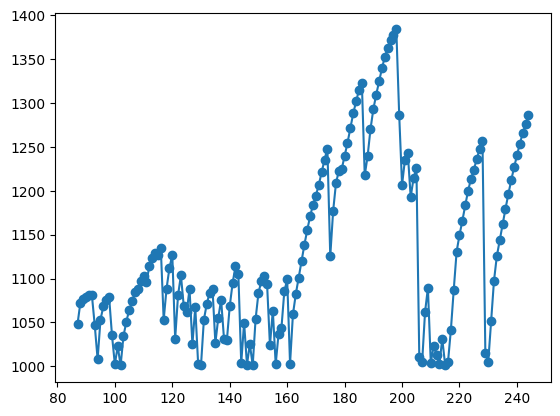

In [35]:
plt.plot(df1[(df1['X']==8.25)&(df1['Z']==260.84)&(df1['t']>86)]['t'],df1[(df1['X']==8.25)&(df1['Z']==260.84)&(df1['t']>86)]['Qv'],'o-')
#plt.plot(df1[(df1['X']==8.25)&(df1['Z']==260.84)&(df1['t']>86)]['t'][:20],df1[(df1['X']==8.25)&(df1['Z']==260.84)&(df1['t']>86)]['Qv'][:20],'o-')
#plt.ylim(0,40000)
#plt.ylabel('saturation (-)')

In [27]:
df1.to_csv(folder+'/data_set_edit_short.txt',index=False)

Text(0, 0.5, 'modeled potential (mV)')

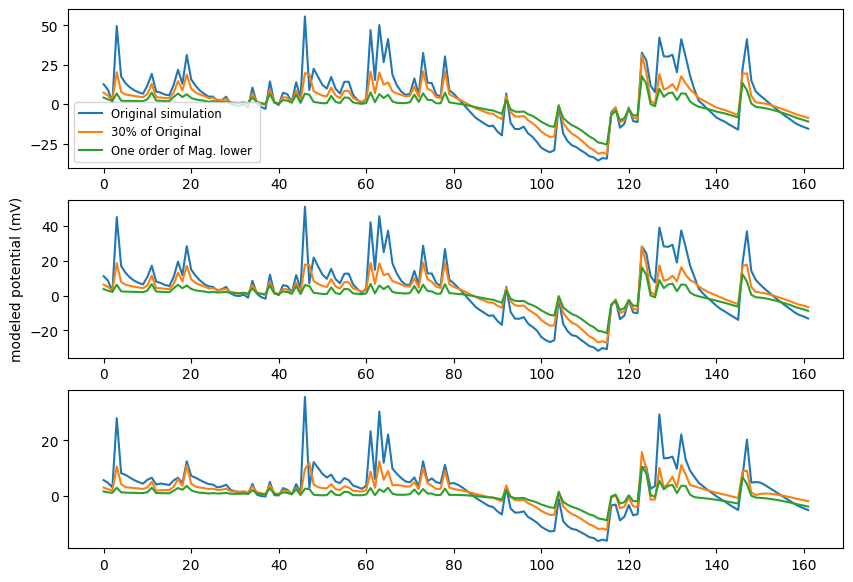

In [84]:
fig,ax=plt.subplots(3,1, figsize=(10,7))
res1=pd.read_csv('Final_short_1/result_short.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
ax[0].plot((res1.iloc[749,85:]-res1.iloc[50,85:]).values*1000, label = "Original simulation")
ax[1].plot((res1.iloc[92,85:]-res1.iloc[50,85:]).values*1000)
ax[2].plot((res1.iloc[511,85:]-res1.iloc[50,85:]).values*1000)

res3=pd.read_csv('Final_short_1_temp/result_short.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
ax[0].plot((res3.iloc[749,85:]-res3.iloc[50,85:]).values*1000, label = "30% of Original")
ax[1].plot((res3.iloc[92,85:]-res3.iloc[50,85:]).values*1000)
ax[2].plot((res3.iloc[511,85:]-res3.iloc[50,85:]).values*1000)

res2=pd.read_csv('Final_short_1_temp4/result_short.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
ax[0].plot((res2.iloc[749,85:]-res2.iloc[50,85:]).values*1000, label = "One order of Mag. lower ")
ax[1].plot((res2.iloc[92,85:]-res2.iloc[50,85:]).values*1000)
ax[2].plot((res2.iloc[511,85:]-res2.iloc[50,85:]).values*1000)
ax[0].legend(loc="lower left", fontsize='small')
#SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[1].set_ylabel('modeled potential (mV)')
#plt.xlim(-30,30)

Text(0, 0.5, 'modeled potential (mV)')

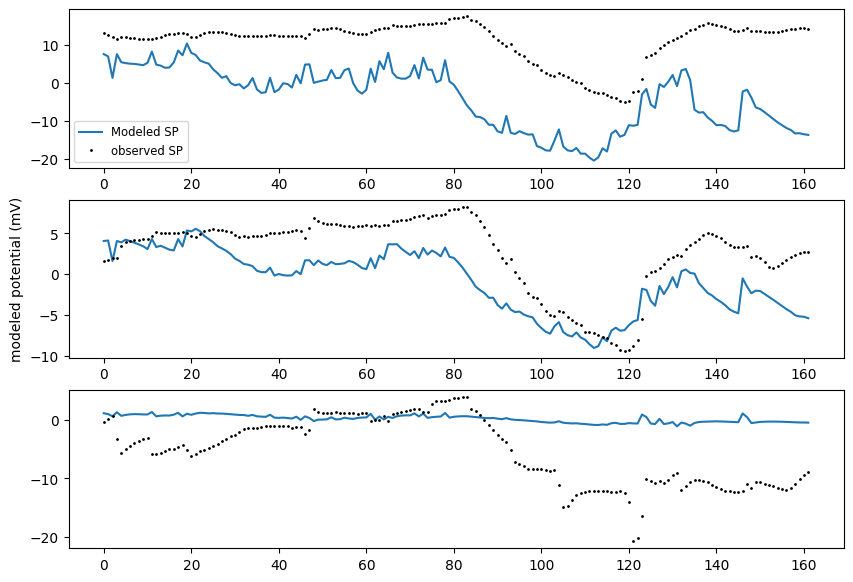

In [28]:
fig,ax=plt.subplots(3,1, figsize=(10,7))
res1=pd.read_csv('Final_short_1_temp5/result_short.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
ax[0].plot((res1.iloc[749,85:]-res1.iloc[50,85:]).values*1000, label = "Modeled SP")
ax[1].plot((res1.iloc[92,85:]-res1.iloc[50,85:]).values*1000)
ax[2].plot((res1.iloc[511,85:]-res1.iloc[50,85:]).values*1000)

SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[0].plot(SP_a,'ko',markersize=1, label='observed SP')
ax[1].plot(SP_b,'ko',markersize=1); ax[2].plot(SP_c,'ko',markersize=1)

ax[0].legend(loc="lower left", fontsize='small')
ax[1].set_ylabel('modeled potential (mV)')
#ax[1].set_ylim(0,5)

Text(0, 0.5, 'modeled SP')

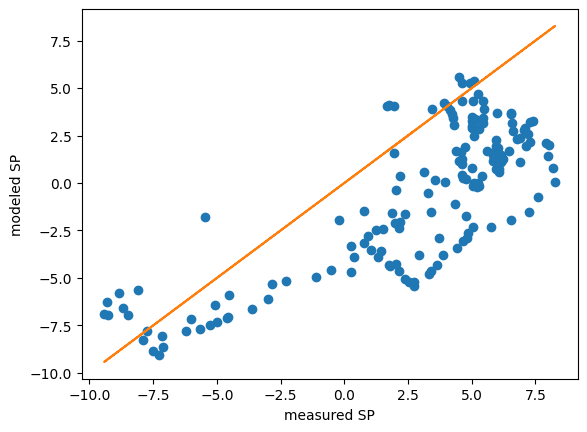

In [32]:
plt.plot(SP_b, (res1.iloc[92,85:]-res1.iloc[50,85:]).values*1000,'o')
plt.plot(SP_b,SP_b)
plt.xlabel('measured SP')
plt.ylabel('modeled SP')

#### junk from initial calib

In [13]:
df=pd.read_csv(folder+'/data_set_edit_short.txt')


In [12]:
for i in range(1,14):
    df.loc[(df['t'] > 500*(i-1)) & (df['t'] < 500*i)].to_csv(folder+'/data_set_edit_short_'+str(i)+'.txt',index=False)

In [2]:
df=pd.concat((pd.read_csv(r'C:\Users\m10921371\OneDrive - Colorado School of Mines\WADE_SFA\Field Data\BSL Site\November 2024\SP\TN_Urban_01_SP.dat',skiprows=1).iloc[2:,:]
           ,pd.read_csv(r'C:\Users\m10921371\OneDrive - Colorado School of Mines\WADE_SFA\Field Data\BSL Site\November 2024\SP\TN_Urban_01_TN_Urban_01_SP.dat',skiprows=1).iloc[2:,:])).reset_index()
df['TIMESTAMP']=pd.to_datetime(df['TIMESTAMP'], format='%Y-%m-%d %H:%M:%S')
df.set_index('TIMESTAMP', inplace=True)
df['SEVolt(1)']=pd.to_numeric(df['SEVolt(1)'], errors='coerce')
df['SEVolt(2)']=pd.to_numeric(df['SEVolt(2)'], errors='coerce')
df['SEVolt(3)']=pd.to_numeric(df['SEVolt(3)'], errors='coerce')
df['SEVolt(4)']=pd.to_numeric(df['SEVolt(4)'], errors='coerce')
df['SEVolt(5)']=pd.to_numeric(df['SEVolt(5)'], errors='coerce')

In [3]:
year = 2024
month = 1
day = 1
number_of_days = 365
times = pd.date_range(f'{year}-{month}-{day} 06:00:00', periods=int(24*number_of_days), freq="1h")

In [4]:
res1=pd.read_csv('short_model_hourly/result_5.txt',skiprows=8,delimiter ='\s+').iloc[:,:502]
res2=pd.read_csv('short_model_hourly/result_6.txt',skiprows=8,delimiter ='\s+').iloc[:,:502]
res3=pd.read_csv('short_model_hourly/result_7.txt',skiprows=8,delimiter ='\s+').iloc[:,:502]
res4=pd.read_csv('short_model_hourly/result_8.txt',skiprows=8,delimiter ='\s+').iloc[:,:502]
A_combo=np.hstack(((res1.iloc[749,2:]-res1.iloc[50,2:]).values*1000,(res2.iloc[749,2:]-res2.iloc[50,2:]).values*1000,
                  (res3.iloc[749,2:]-res3.iloc[50,2:]).values*1000,(res4.iloc[749,2:]-res4.iloc[50,2:]).values*1000))
B_combo=np.hstack(((res1.iloc[92,2:]-res1.iloc[50,2:]).values*1000,(res2.iloc[92,2:]-res2.iloc[50,2:]).values*1000,
                  (res3.iloc[92,2:]-res3.iloc[50,2:]).values*1000,(res4.iloc[92,2:]-res4.iloc[50,2:]).values*1000))
C_combo=np.hstack(((res1.iloc[511,2:]-res1.iloc[50,2:]).values*1000,(res2.iloc[511,2:]-res2.iloc[50,2:]).values*1000,
                  (res3.iloc[511,2:]-res3.iloc[50,2:]).values*1000,(res4.iloc[511,2:]-res4.iloc[50,2:]).values*1000))
i=5;
j=8
t_plot=times[500*(i-1)-1:(500*(j-1)-1)+500]
combo=pd.DataFrame({"A":A_combo,"B":B_combo, "C":C_combo},index=t_plot)


In [15]:
kk=np.hstack(((df['SEVolt(1)']-df['SEVolt(4)']).values,(df['SEVolt(2)']-df['SEVolt(4)']).values,(df['SEVolt(3)']-df['SEVolt(4)']).values)).T

In [21]:
np.savetxt('observation.txt', kk)

Text(0, 0.5, 'modeled potential (mV)')

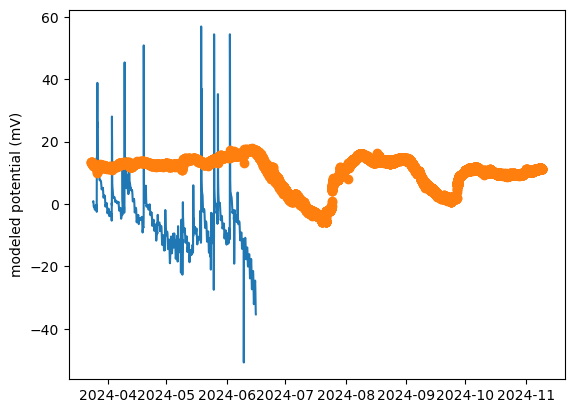

In [43]:
plt.plot(combo.A)
plt.plot(df['SEVolt(1)']-df['SEVolt(4)'],'o')
#plt.plot(combo.B)
#plt.plot(df['SEVolt(2)']-df['SEVolt(4)'])
#plt.plot(combo.C)

#SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
plt.ylabel('modeled potential (mV)')
#plt.xlim(-30,30)

In [ ]:
cp .\post_run.py param1
cp .\post_run.py param2
cp .\post_run.py param3
cp .\post_run.py param4
cp .\post_run.py param5
cp .\post_run.py param6
cp .\post_run.py param7
cp .\post_run.py param8
cp .\post_run.py param9

### Some other stuff

In [68]:
grid_x,grid_y=np.mgrid[0:100:2000j, 257:261.5:60j]
time=107#183#107,#213
grid_U=griddata((df1[(df1['t']==time)&(df1['X']<=100)&(df1['Z']>254.52)]['X'].values,
                df1[(df1['t']==time)&(df1['X']<=100)&(df1['Z']>254.52)]['Z'].values),
               df1[(df1['t']==time)&(df1['X']<=100)&(df1['Z']>254.52)]['U'].values,(grid_x, grid_y),
               method='linear',fill_value='NaN')
grid_W=griddata((df1[(df1['t']==time)&(df1['X']<=100)&(df1['Z']>254.52)]['X'].values,
                df1[(df1['t']==time)&(df1['X']<=100)&(df1['Z']>254.52)]['Z'].values),
               df1[(df1['t']==time)&(df1['X']<=100)&(df1['Z']>254.52)]['W'].values,(grid_x, grid_y),
               method='linear',fill_value='NaN')
grid_sat=griddata((df1[(df1['t']==time)&(df1['X']<=100)&(df1['Z']>254.52)]['X'].values,
                df1[(df1['t']==time)&(df1['X']<=100)&(df1['Z']>254.52)]['Z'].values),
               df1[(df1['t']==time)&(df1['X']<=100)&(df1['Z']>254.52)]['sat'].values,(grid_x, grid_y),
               method='linear',fill_value='NaN')

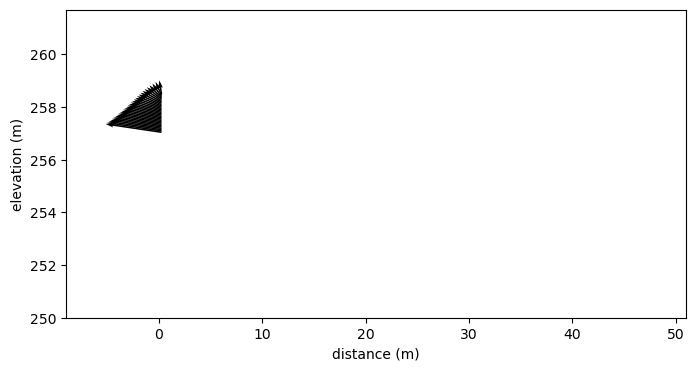

In [69]:
fig,ax = plt.subplots(1,1, figsize=(8,4))
#sat=ax.contourf(grid_x,grid_y,grid_sat,cmap='viridis',levels=np.arange(0.8,1,0.001),extend='both')
ax.quiver(df1[(df1['t']==time)&(df1['X']==0.25)&(df1['Z']>257)]['X'].values,
          df1[(df1['t']==time)&(df1['X']==0.25)&(df1['Z']>257)]['Z'].values,
          df1[(df1['t']==time)&(df1['X']==0.25)&(df1['Z']>257)]['U'].values,
          df1[(df1['t']==time)&(df1['X']==0.25)&(df1['Z']>257)]['W'].values,color='black',width=0.0025)#,angles='xy',scale_units='xy',scale=1)
ax.set_xlim(-9,51)
ax.set_ylim(250,261.7)
#plt.plot(np.loadtxt('input_file/top_elevation.txt')[1],np.loadtxt('input_file/top_elevation.txt')[0])
#ax.fill_between(np.loadtxt('input_file/top_elevation.txt')[1],np.loadtxt('input_file/top_elevation.txt')[0],
#               np.loadtxt('input_file/top_elevation.txt')[0].max(), where=(np.loadtxt('input_file/top_elevation.txt')[0]>
#                np.loadtxt('input_file/top_elevation.txt')[0].max()),color='white',zorder=1)
ax.set_xlabel('distance (m)')
ax.set_ylabel('elevation (m)')
fig.colorbar(sat, label= 'saturation')
plt.savefig('junk.svg')

In [99]:
### Example from Voytek et al 2019

#sat=np.arange(0.1,1.01,0.01)
#res_sat=0.06
#m_vg=(1.58-1)/1.58
#eff_sat=(sat-res_sat)/(1-res_sat)
#rel_perm=eff_sat**0.5*(1-(1-eff_sat**(1/m_vg))**m_vg)**2
#phi=0.38
#m=2
#tau=phi**(1-m)
#e0 = 1.602e-19   # Elementary charge (C)   
#C0=800*1.3e-5 # fluid conc. from 0.08 S/m using eqn from Griffin and Jurinak
#zeta=-0.00643+0.02085*np.log10(C0)
#E=80.1*8.854e-12 # F/m
#kB=1.381e-23
#T=273.15+20
#k=0.00086*8.3e-6/1000/9.81
#Qv=(E*(-zeta-zeta**3*(((e0) / ( kB * T))**2)/54)*(1 / tau**2) * (phi / k))*eff_sat/rel_perm

In [55]:
res.iloc[[749,92,511,50],:]

,%,x,y,V,(V),@,t=0,V.1,(V).1,@.1,...,@.58,t=58,V.59,(V).59,@.59,t=59,V.60,(V).60,@.60,t=60
749,0.049758,258.300653,-0.002708,-0.001488,-0.000770,-0.000464,-0.000319,-0.000247,-0.000142,-0.000119,...,0.000003,0.000001,1.417683e-08,-0.000001,-0.000003,-0.000004,-0.000005,-0.000006,-0.000007,-0.000007
92,1.721631,259.046310,-13.288205,0.812377,0.284417,0.159618,0.105050,0.078703,0.039954,0.035779,...,0.001853,0.002491,3.021729e-03,0.003478,0.003879,0.004205,0.004606,0.004753,0.005361,0.005352
511,4.323629,259.826889,-8.450925,1.742810,0.911215,0.594449,0.412165,0.322412,0.170013,0.149323,...,0.000583,0.002949,5.080805e-03,0.007032,0.008807,0.010362,0.011985,0.013112,0.013813,0.014652
50,8.005665,260.552942,-9.439098,1.987181,1.075364,0.728208,0.520093,0.417120,0.215430,0.202746,...,-0.003477,0.000009,3.250790e-03,0.006283,0.009175,0.011803,0.014534,0.016628,0.018000,0.019608


Text(0, 0.5, 'modeled potential (mV)')

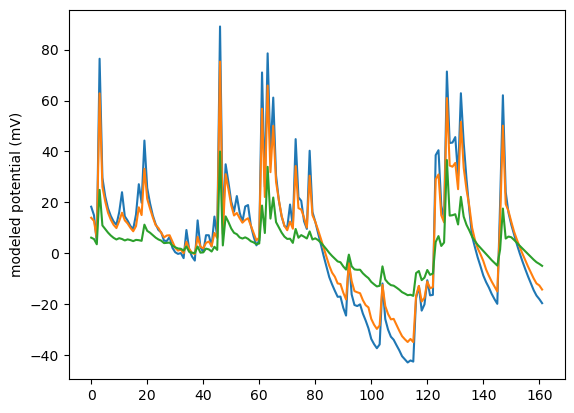

In [54]:
res=pd.read_csv('short_model_calib/result_short.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
plt.plot((res.iloc[749,85:]-res.iloc[50,85:]).values*1000)

plt.plot((res.iloc[92,85:]-res.iloc[50,85:]).values*1000)

plt.plot((res.iloc[511,85:]-res.iloc[50,85:]).values*1000)

#SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
plt.ylabel('modeled potential (mV)')
#plt.xlim(-30,30)

In [42]:
(res.iloc[749,85:]-res.iloc[50,85:]).values*1000

array([-2.42547661e+02, -4.35470398e+02, -8.29473047e+02, -1.72748925e+02,
       -6.28749423e+02, -6.07036083e+02, -6.22180833e+02, -5.92295470e+02,
       -5.67985675e+02, -5.47908380e+02, -3.60884740e+02, -9.55751050e+01,
       -5.49599465e+02, -5.64125118e+02, -5.94693120e+02, -5.19414089e+02,
       -7.55928821e+01, -7.86394158e+01, -1.34181616e+02, -8.00966356e+01,
       -4.15938933e+02, -5.36825764e+02, -6.33248935e+02, -5.82566216e+02,
       -5.15776990e+02, -6.66586114e+02, -6.87128636e+02, -6.55611429e+02,
       -4.87425032e+02, -7.62202220e+02, -8.09145037e+02, -7.58167830e+02,
       -8.62008284e+02, -6.18014542e+02,  2.34234667e+02, -7.73296411e+02,
       -8.99603237e+02, -7.90010994e+02,  7.84924803e+01, -8.33020983e+02,
       -6.64702160e+02, -1.92144756e+02, -3.21310118e+02, -6.06573275e+02,
        2.91468826e+01, -5.23426354e+02,  6.10348484e+01, -8.17537393e+00,
       -6.71191907e+02, -7.25869374e+02, -5.87552751e+02, -5.66940326e+02,
        9.48271245e+01, -

In [31]:
res=pd.read_csv('result_short.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
np.hstack(((res.iloc[749,85:]-res.iloc[50,85:]).values*1000,(res.iloc[92,85:]-res.iloc[50,85:]).values*1000,(res.iloc[511,85:]-res.iloc[50,85:]).values*1000))

(486,)

In [37]:
with open("matlab_signal.txt", "w") as f:
        f.write("wait")

In [21]:
params=np.array([2.26e-14,4.9e-05,1.426455636,0.229866989])
np.savetxt('short_model_calib/params.txt',params)

In [44]:
np.loadtxt('short_model_calib/tst.txt')[1]

4.9e-05

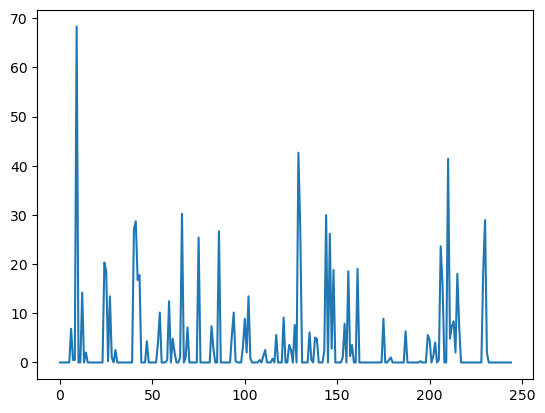

In [32]:
w_b=pd.read_csv('1yr_run/water_balance.dat',skiprows=112)
plt.plot(w_b['rain precipitation [m d^-1]']*1000)

In [ ]:
pd.read_

In [15]:
np.savetxt('data/SP_a_model.csv',(res.iloc[105,85:]-res.iloc[138,85:]).values*1000)
np.savetxt('data/SP_b_model.csv',(res.iloc[167,85:]-res.iloc[138,85:]).values*1000)
np.savetxt('data/SP_c_model.csv',(res.iloc[3559,85:]-res.iloc[138,85:]).values*1000)

In [18]:
SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)

In [28]:
res[(res.iloc[:,0]<=8.5)&(res.iloc[:,0]>=7.5)&(res.iloc[:,1]>=259.5)]#85

,%,x,y,V,(V),@,t=0,V.1,(V).1,@.1,...,@.58,t=58,V.59,(V).59,@.59,t=59,V.60,(V).60,@.60,t=60
27,8.417000,260.598026,-1.060289,0.118623,0.081635,0.069628,0.062207,0.057436,0.038588,0.040391,...,-0.001120,0.000287,0.001514,0.002644,0.003706,0.004644,0.005555,0.006343,0.007088,0.007554
28,8.191932,260.909712,-1.054578,0.118535,0.081651,0.069645,0.062240,0.056760,0.001721,0.022770,...,-0.000604,0.000949,0.002319,0.003587,0.004780,0.005840,0.006871,0.007749,0.008605,0.009124
50,8.005665,260.552942,-1.048391,0.118426,0.081639,0.069648,0.062256,0.057502,0.039351,0.040998,...,-0.000942,0.000432,0.001628,0.002725,0.003755,0.004661,0.005538,0.006293,0.007009,0.007447
51,7.765577,260.868598,-1.042263,0.118334,0.081650,0.069668,0.062295,0.056835,0.002190,0.023096,...,-0.000418,0.001099,0.002435,0.003668,0.004827,0.005850,0.006843,0.007686,0.008513,0.008999
52,7.585396,260.512698,-1.035517,0.118218,0.081628,0.069667,0.062311,0.057580,0.039868,0.041259,...,-0.000731,0.000614,0.001781,0.002850,0.003851,0.004726,0.005571,0.006294,0.006982,0.007391
292,8.236226,260.244068,-1.054318,0.118566,0.081674,0.069665,0.062246,0.057506,0.038994,0.043889,...,-0.001001,0.000174,0.001180,0.002094,0.002947,0.003686,0.004404,0.005008,0.005600,0.005921
293,8.475376,260.012625,-1.060841,0.118750,0.081721,0.069703,0.062261,0.057559,0.038997,0.043755,...,-0.000732,0.000294,0.001168,0.001955,0.002685,0.003310,0.003920,0.004420,0.004920,0.005161
326,7.832788,260.189629,-1.042080,0.118339,0.081662,0.069665,0.062289,0.057553,0.039515,0.044183,...,-0.000798,0.000342,0.001314,0.002193,0.003013,0.003717,0.004399,0.004969,0.005530,0.005822
328,8.115512,259.842765,-1.050268,0.118514,0.081727,0.069693,0.062214,0.057341,0.039221,0.043212,...,-0.000341,0.000582,0.001361,0.002057,0.002697,0.003235,0.003762,0.004182,0.004613,0.004795
372,7.650191,259.823481,-1.035151,0.118222,0.081692,0.069668,0.062246,0.057414,0.039761,0.043526,...,-0.000195,0.000717,0.001481,0.002161,0.002787,0.003306,0.003813,0.004216,0.004631,0.004798


Text(0, 0.5, 'error [m]')

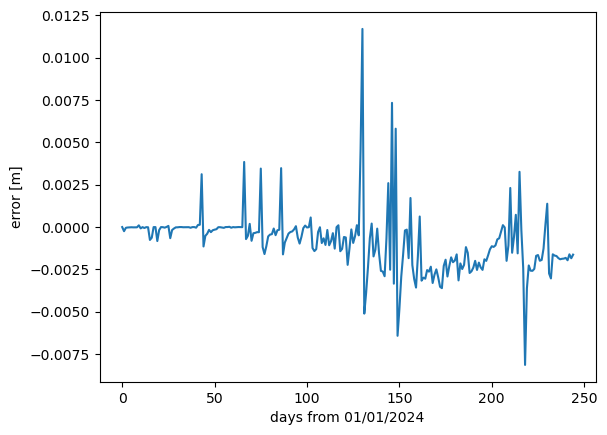

In [13]:
w_b=pd.read_csv('1yr_run/water_balance.dat',skiprows=112)
area=300 #m^3
err=w_b['snowmelt [m d^-1]']+w_b['rain precipitation [m d^-1]']-w_b['evapotranspiration [m d^-1]'
            ]-w_b['runoff generation [mol d^-1]']/55000/area+w_b['exfiltration [mol d^-1]']/55000/area
plt.plot(err)
plt.xlabel ('days from 01/01/2024')
plt.ylabel ('error [m]')

In [10]:
def plot_labend(i):
    ax[i].set_xticklabels([])
    ax[i].xaxis.set_major_locator(mdates.DayLocator(interval=10))
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax[i].set_xlim(datetime.strptime('2024/03/22 06:00:00', '%Y/%m/%d %H:%M:%S'),datetime.strptime('2024/08/31 00:00:00', '%Y/%m/%d %H:%M:%S'))
    ax[i].set_xlabel('date', fontsize=14)
    ax[i].tick_params(axis='x', labelsize=14)
    ax[i].grid(visible=True, linestyle='--', linewidth=0.8, alpha=0.7)

In [32]:
res=pd.read_csv('1yr_run/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]

SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)

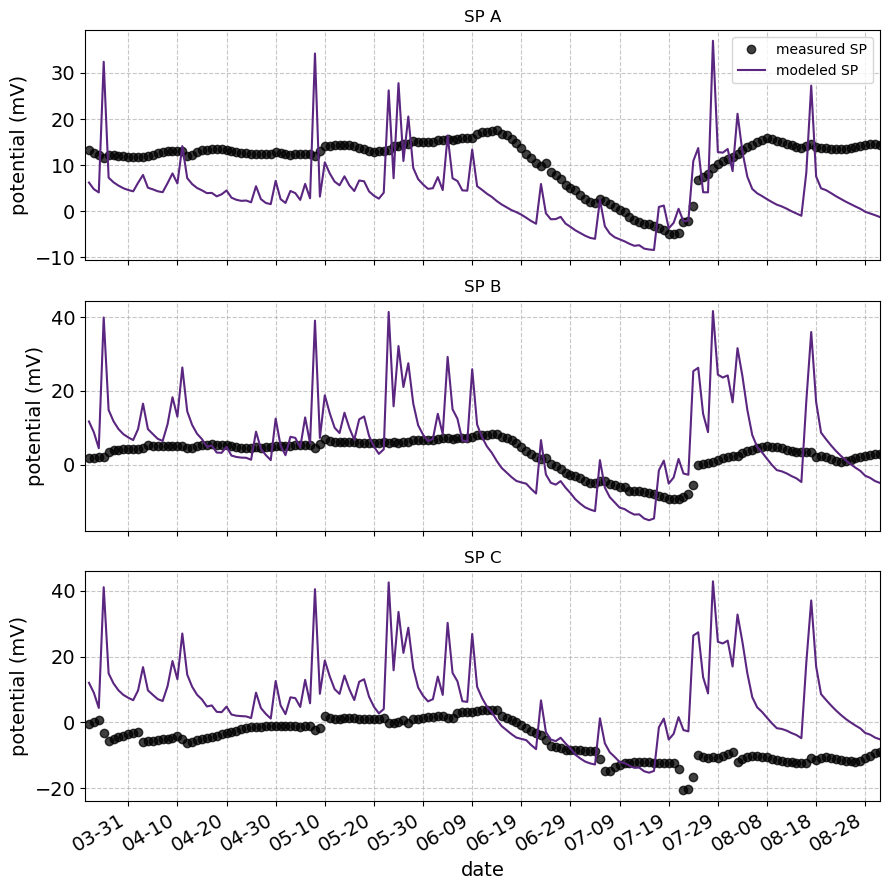

In [14]:
fig,ax=plt.subplots(3,1, figsize=(9,9))
ax[0].plot(np.datetime64("2024-03-23")+np.arange(162),SP_a,'ko', alpha=0.75,label='measured SP')
ax[0].plot(np.datetime64("2024-03-23")+np.arange(162),(res.iloc[105,85:]-res.iloc[138,85:]).values*1000,color='#5A2680',label='modeled SP')
ax[1].plot(np.datetime64("2024-03-23")+np.arange(162),SP_b,'ko', alpha=0.75)
ax[1].plot(np.datetime64("2024-03-23")+np.arange(162),(res.iloc[167,85:]-res.iloc[138,85:]).values*1000,color='#5A2680')
ax[2].plot(np.datetime64("2024-03-23")+np.arange(162),SP_c,'ko', alpha=0.75)
ax[2].plot(np.datetime64("2024-03-23")+np.arange(162),(res.iloc[3559,85:]-res.iloc[138,85:]).values*1000,color='#5A2680')
ax[0].set_title('SP A')
ax[1].set_title('SP B')
ax[2].set_title('SP C')
ax[0].set_ylabel('potential (mV)', fontsize=14)
ax[1].set_ylabel('potential (mV)', fontsize=14)
ax[2].set_ylabel('potential (mV)', fontsize=14)
ax[0].tick_params(axis='y', labelsize=14)
ax[1].tick_params(axis='y', labelsize=14)
ax[2].tick_params(axis='y', labelsize=14)
ax[0].legend()


plot_labend(0)
plot_labend(1)
plot_labend(2)
fig.autofmt_xdate()
fig.tight_layout()
plt.savefig('SP_model.svg')

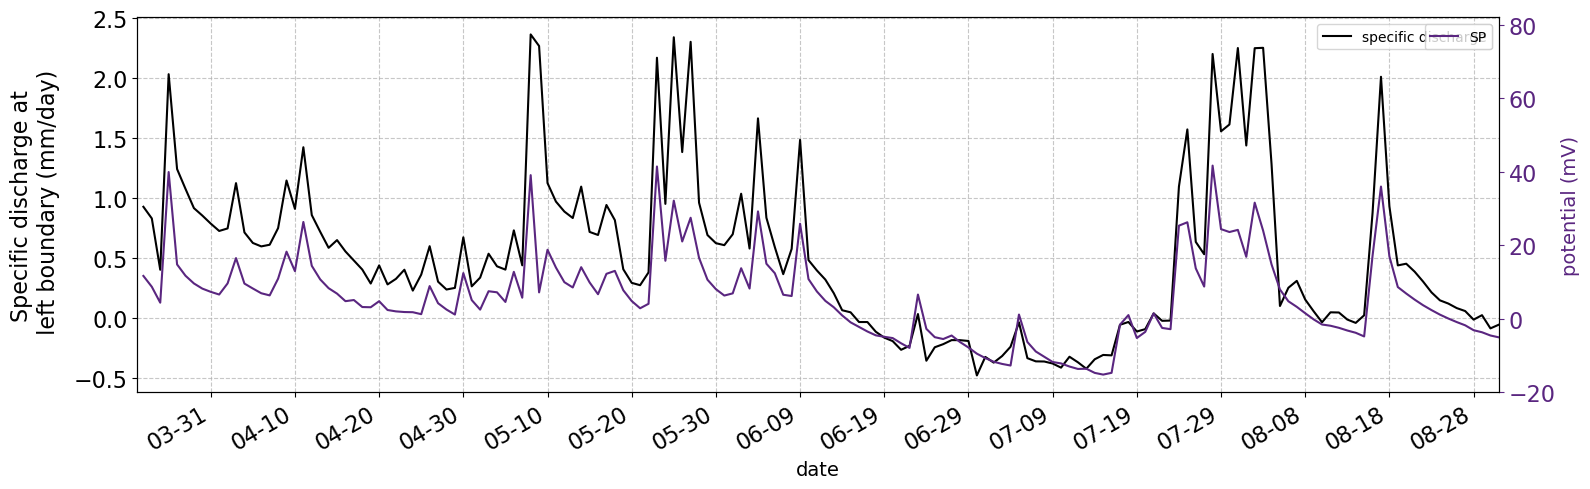

In [26]:
flux=pd.read_csv('flux_save.csv')
fig,ax=plt.subplots(figsize=(16,5))
ax.plot(np.datetime64("2024-03-23")+np.arange(162),-flux*86400000,'k', label='specific discharge')
ax.set_xticklabels([])
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.set_xlim(datetime.strptime('2024/03/22 06:00:00', '%Y/%m/%d %H:%M:%S'),datetime.strptime('2024/08/31 00:00:00', '%Y/%m/%d %H:%M:%S'))
ax.set_xlabel('date', fontsize=14)
ax.set_ylabel('Specific discharge at\n left boundary (mm/day)', fontsize=16,labelpad=10)
ax.grid(visible=True, linestyle='--', linewidth=0.8, alpha=0.7)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.legend()
ax0=ax.twinx()
ax0.plot(np.datetime64("2024-03-23")+np.arange(162),(res.iloc[167,85:]-res.iloc[138,85:]).values*1000,color='#5A2680', label='SP')
ax0.tick_params(axis='y', labelsize=16,colors='#5A2680')
ax0.set_ylabel('potential (mV)', fontsize=14,color='#5A2680')
ax0.legend()
ax0.set_ylim(-20,82)
fig.autofmt_xdate()
fig.tight_layout()
plt.savefig('flux_model.svg')

In [82]:
from Read_data import convert
import time
import numpy as np
for i in range (25,100):
    convert('Perm_ens/Perm_ens_'+str(i))

In [173]:
residual={}
a_all={}
b_all={}
c_all={}
d_all={}
for i in range(1,91):
    df=pd.read_csv('Perm_ens/Perm_ens_'+str(i)+'/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
    SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
    SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
    SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
    a=((df.iloc[1071,85:]).values*1000)
    b=((df.iloc[1312,85:]).values*1000)
    c=((df.iloc[759,85:]).values*1000)
    d=((df.iloc[708,85:]).values*1000)
    residual[i]=sum((SP_a-a)**2),sum((SP_b-b)**2),sum((SP_c-c)**2),(sum((SP_a-a)**2)+sum((SP_b-b)**2)+sum((SP_c-c)**2))
    a_all[i]=a
    b_all[i]=b
    c_all[i]=c
    d_all[i]=d
#(pd.DataFrame(residual).T).to_csv('data/perm_ens_residual.txt',index=False,header=None)


ValueError: operands could not be broadcast together with shapes (161,) (164,) 

In [ ]:
(pd.DataFrame(a_all).T).to_csv('data/perm_ens_data_a.txt',index=False)
(pd.DataFrame(b_all).T).to_csv('data/perm_ens_data_b.txt',index=False)
(pd.DataFrame(c_all).T).to_csv('data/perm_ens_data_c.txt',index=False)
(pd.DataFrame(d_all).T).to_csv('data/perm_ens_data_d.txt',index=False)

In [107]:
perm_a_all=a_all
perm_b_all=b_all
perm_c_all=c_all
perm_d_all=d_all

In [ ]:
a_all=a_all
b_all=b_all
c_all=c_all
d_all=d_all

In [101]:
pd.DataFrame(a_all).T

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
1,0.069439,0.062592,0.132297,0.185212,0.119966,0.077075,0.062489,0.056576,0.053130,0.053120,...,0.478442,0.513323,0.534579,0.539909,0.534927,0.507566,0.537141,0.454465,0.502638,0.456766
2,0.000094,0.000086,0.001145,0.002614,0.001451,0.000496,0.000116,0.000113,0.000081,-0.000010,...,0.010216,0.010988,0.011494,0.011362,0.011194,0.011047,0.011675,0.009842,0.011035,0.009999
3,3.299896,3.024781,4.769326,3.938990,3.406462,3.291132,3.258195,3.200250,3.187462,3.304813,...,11.733659,11.980531,12.236136,12.148565,12.003919,11.859263,11.764568,11.591732,11.472850,11.287996
4,1.419029,1.554603,1.827168,1.755264,1.726423,1.653070,1.567597,1.509609,1.424610,1.372596,...,2.400017,2.388292,2.382726,2.373336,2.365635,2.353212,2.358539,2.335232,2.356128,2.328481
5,-0.000396,-0.000432,-0.000781,-0.000301,-0.000374,-0.000429,-0.000434,-0.000397,-0.000376,-0.000439,...,0.001111,0.001262,0.001353,0.001358,0.001348,0.001357,0.001448,0.001319,0.001378,0.001275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,0.000162,0.000160,0.001405,0.003049,0.001666,0.000623,0.000202,0.000189,0.000149,0.000061,...,0.011607,0.012498,0.013040,0.012865,0.012713,0.012428,0.013244,0.011150,0.012488,0.011314
87,3.383527,2.912239,5.081409,4.108650,3.688530,3.583280,3.571419,3.530369,3.477884,3.546680,...,16.804783,16.636535,16.564639,16.494777,16.407062,16.982187,17.350751,17.050510,16.816650,16.495608
88,11.204911,8.613020,15.899113,15.403202,14.376634,13.666350,13.101481,12.319559,11.572605,11.256916,...,34.105599,33.467093,32.989546,32.585066,32.196972,31.838736,31.525194,31.371344,31.041799,30.744403
89,0.001262,0.001213,0.005016,0.009434,0.005655,0.002705,0.001445,0.001353,0.001236,0.001125,...,0.031841,0.034253,0.035616,0.035145,0.034653,0.033811,0.035893,0.030307,0.033888,0.030865


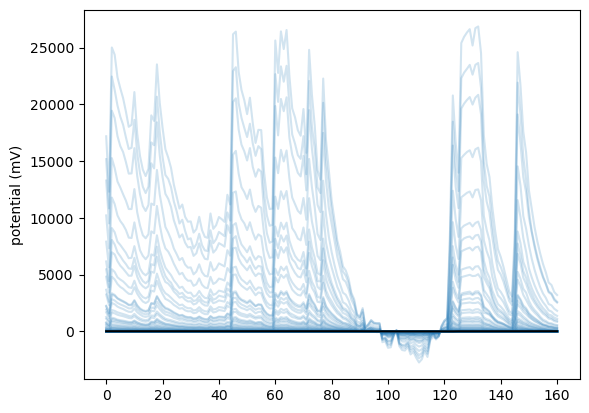

In [112]:
plt.plot((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T).T,'#2278B5',alpha=0.2)
plt.plot(SP_a,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.show()

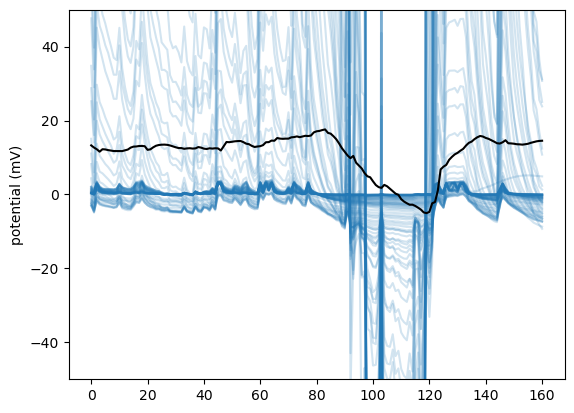

In [113]:
plt.plot((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T).T,'#2278B5',alpha=0.2)
plt.plot(SP_a,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

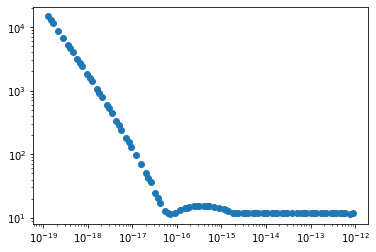

In [81]:
perm_ens=pd.read_csv('data/perm_ensemble_parameters.csv').iloc[:90,:]
#perm_ens.values.reshape(-1,)
plt.plot(perm_ens,((((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T)-SP_a)**2).mean(axis=1))**0.5,'o')
plt.xscale('log')
plt.yscale('log')

In [150]:
np.argmax((((((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T)-SP_a)**2).mean(axis=1))**0.5).values)

62

In [153]:
perm_ens.values[84]

array([8.81683067e-13])

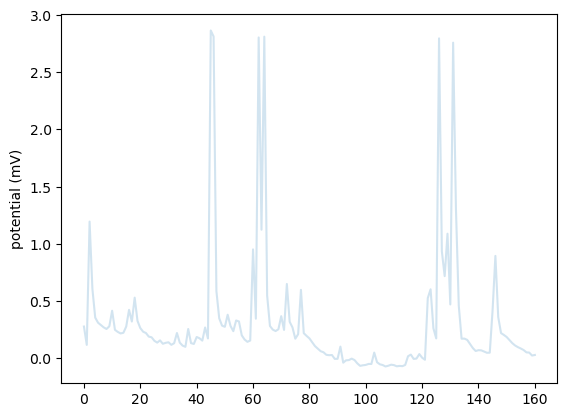

In [155]:
plt.plot((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T).T.iloc[:,84],'#2278B5',alpha=0.2)
#plt.plot(SP_a,'k-',markersize=3)
plt.ylabel('potential (mV)')
#plt.ylim(-50,50)
plt.show()

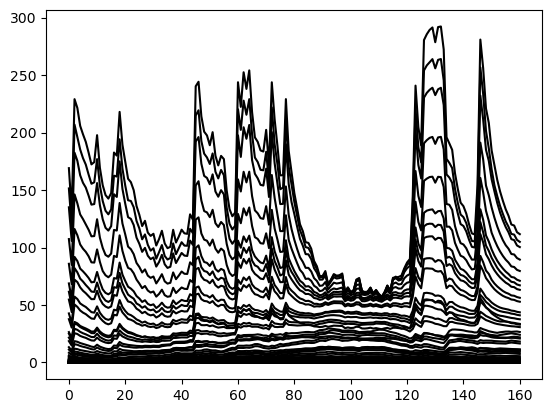

In [105]:
plt.plot(pd.DataFrame(a_all),'k')
plt.show()

In [9]:
pd.DataFrame(b_all).T

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
1,2.132059,2.679977,1.924926,1.832257,1.792088,1.744456,1.714469,1.718306,1.758323,1.728219,...,1.137915,1.320690,1.457981,1.700962,1.799337,1.633440,1.737643,1.534041,1.686641,1.571223
2,-0.055663,-0.017834,-0.090481,-0.043972,-0.037063,-0.043288,-0.046012,-0.044471,-0.040424,-0.045294,...,0.036280,0.044159,0.050510,0.050793,0.051675,0.052320,0.058660,0.051311,0.066305,0.062307
3,-63.895710,-39.243761,-100.224302,-95.573067,-85.751271,-80.419656,-75.955567,-70.827541,-65.349557,-63.450461,...,-12.419037,-1.596787,6.898854,11.416062,15.832136,18.837504,23.469670,23.921440,26.967476,27.555091
4,-0.527449,2.997985,-3.775198,-3.431726,-2.234061,-1.403384,-0.888634,-0.369298,0.315120,0.777529,...,4.075908,4.813862,5.447228,5.993584,6.526642,6.929949,7.414171,7.527450,8.107975,8.040035
5,-0.028168,-0.009212,-0.074422,-0.035039,-0.030875,-0.027325,-0.025030,-0.022697,-0.020717,-0.022213,...,-0.004795,-0.001714,0.000356,0.000849,0.001630,0.002471,0.003266,0.004337,0.006640,0.006806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,-0.065821,-0.022444,-0.093430,-0.045596,-0.044595,-0.050163,-0.052269,-0.049913,-0.044624,-0.049963,...,0.036314,0.046344,0.053937,0.055019,0.056711,0.057289,0.066393,0.056145,0.073968,0.069021
87,-77.162713,-48.600438,-118.501589,-114.934486,-106.071132,-99.116943,-93.749781,-87.160041,-80.368706,-76.714788,...,-12.377989,-4.102118,3.141144,8.683028,14.109757,22.002299,28.818585,28.883371,31.522333,31.937380
88,-288.825105,-200.929097,-420.729992,-402.591264,-369.637008,-350.697979,-336.364081,-315.084571,-294.808182,-286.311391,...,-108.901366,-84.014985,-61.949989,-43.933390,-27.384641,-14.115245,2.686951,6.632933,18.401410,21.567438
89,-0.110853,-0.054076,-0.142015,-0.069533,-0.058334,-0.075102,-0.085781,-0.085848,-0.081057,-0.088352,...,0.107853,0.128800,0.142340,0.145976,0.149616,0.150617,0.166075,0.145398,0.174984,0.166104


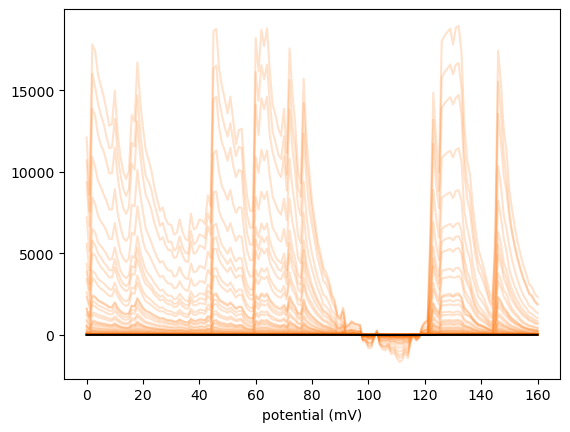

In [114]:
plt.plot((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T).T,'#FF6F00',alpha=0.2)
plt.plot(SP_b,'k-',markersize=3)
plt.xlabel('potential (mV)')
plt.show()

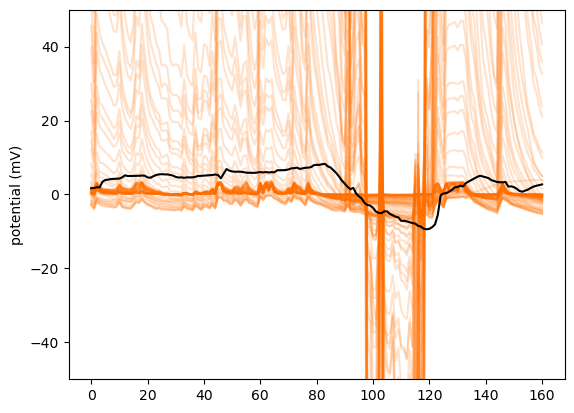

In [115]:
plt.plot((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T).T,'#FF6F00',alpha=0.2)
plt.plot(SP_b,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

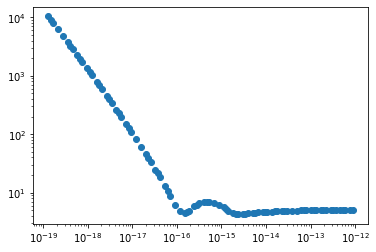

In [87]:
perm_ens=pd.read_csv('data/perm_ensemble_parameters.csv').iloc[:90,:]
#perm_ens.values.reshape(-1,)
plt.plot(perm_ens,((((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T)-SP_b)**2).mean(axis=1))**0.5,'o')
plt.xscale('log')
plt.yscale('log')

In [89]:
np.argmin((((((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T)-SP_b)**2).mean(axis=1))**0.5).values)

5

In [90]:
perm_ens.values[5]

array([2.37137371e-15])

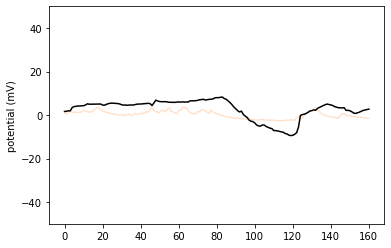

In [97]:
plt.plot((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T).T.iloc[:,5],'#FF6F00',alpha=0.2)
plt.plot(SP_b,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

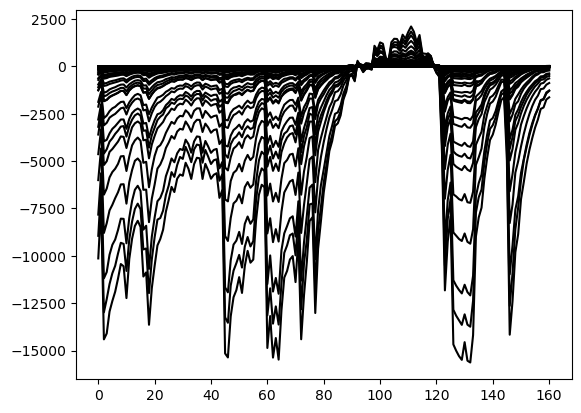

In [107]:
plt.plot(pd.DataFrame(c_all),'k')
plt.show()

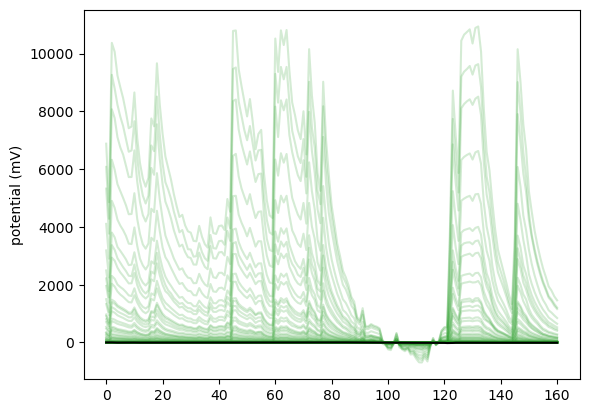

In [116]:
plt.plot((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T).T,'#2A9F2A',alpha=0.2)
plt.plot(SP_c,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.show()

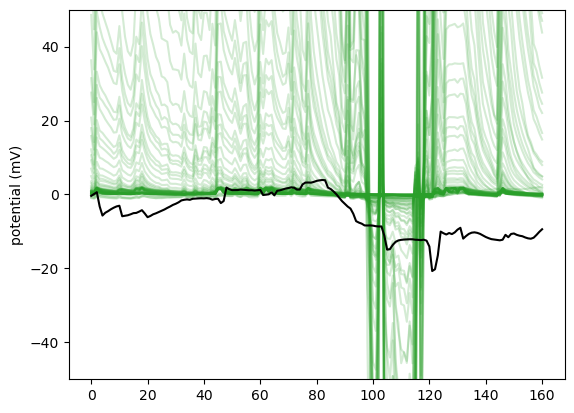

In [119]:
plt.plot((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T).T,'#2A9F2A',alpha=0.2)
plt.plot(SP_c,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

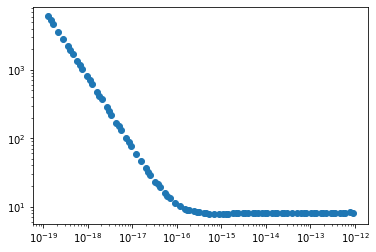

In [99]:
perm_ens=pd.read_csv('data/perm_ensemble_parameters.csv').iloc[:90,:]
#perm_ens.values.reshape(-1,)
plt.plot(perm_ens,((((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T)-SP_c)**2).mean(axis=1))**0.5,'o')
plt.xscale('log')
plt.yscale('log')

In [102]:
np.argmin((((((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T)-SP_c)**2).mean(axis=1))**0.5).values)

13

In [103]:
perm_ens.values[13]

array([8.65964323e-16])

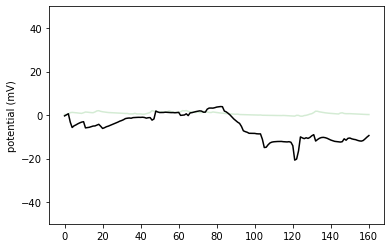

In [106]:
plt.plot((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T).T.iloc[:,5],'#2A9F2A',alpha=0.2)
plt.plot(SP_c,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

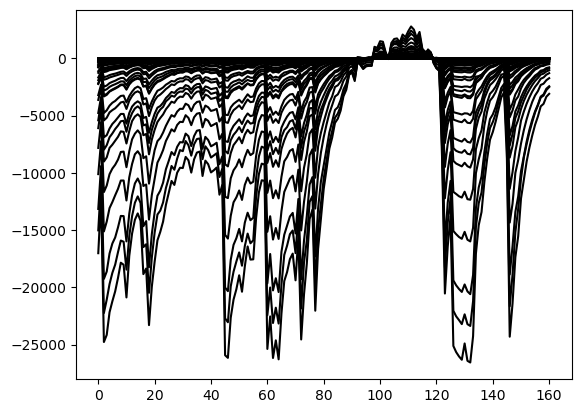

In [109]:
plt.plot(pd.DataFrame(d_all),'k')
plt.show()

In [187]:
a_all=(pd.DataFrame(a_all).where(pd.DataFrame(a_all) >= -150, np.nan)).T.dropna().T
b_all=(pd.DataFrame(b_all).where(pd.DataFrame(b_all) >= -150, np.nan)).T.dropna().T
c_all=(pd.DataFrame(c_all).where(pd.DataFrame(c_all) >= -150, np.nan)).T.dropna().T

In [110]:
from Read_data import convert
import time
import numpy as np
for i in range (1,31):
    convert('Alpha_ens/Alpha_ens_'+str(i))

KeyboardInterrupt: 

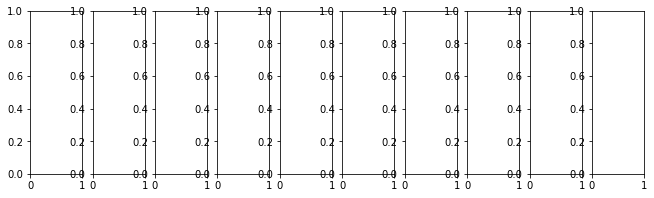

In [111]:
residual={}
a_all={}
b_all={}
c_all={}
d_all={}
#fig,ax=plt.subplots(1,1, figsize=(11,3))
for i in range(1,30):
    df=pd.read_csv('Alpha_ens/Alpha_ens_'+str(i)+'/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
    SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
    SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
    SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
    a=((df.iloc[1071,85:]).values*1000)
    b=((df.iloc[1312,85:]).values*1000)
    c=((df.iloc[759,85:]).values*1000)
    d=((df.iloc[708,85:]).values*1000)
    #residual[i]=sum((SP_a-a)**2),sum((SP_b-b)**2),sum((SP_c-c)**2),(sum((SP_a-a)**2)+sum((SP_b-b)**2)+sum((SP_c-c)**2))
    a_all[i]=a
    b_all[i]=b
    c_all[i]=c
    d_all[i]=d
#(pd.DataFrame(residual).T).to_csv('data/alpha_ens_residual.txt',index=False,header=None)

FileNotFoundError: [Errno 2] No such file or directory: 'Perm_ens/Perm_ens_91/data_set_edit.txt'

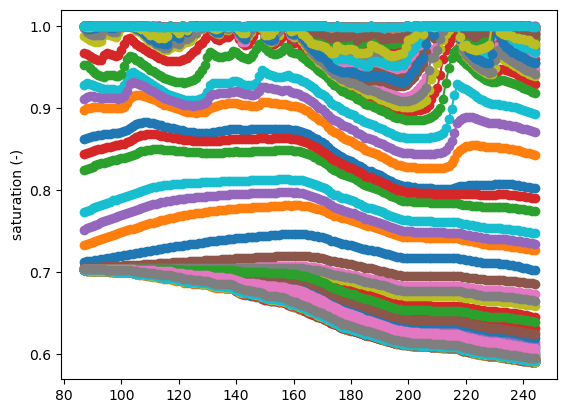

In [200]:
for i in range(1,100):#array([1,14,17,30])
    df1=pd.read_csv('Perm_ens/Perm_ens_'+str(i)+'/data_set_edit.txt',skiprows=8,delimiter =',', header=None).iloc[:,:247]
    df1.columns = ['X', 'Z', 't', 'U','W', 'Por','sat','cond','Perm','m','Qv']
    df1[(df1['X']==4.25)&(df1['Z']==259.79225)]
    plt.plot(df1[(df1['X']==4.25)&(df1['Z']==259.79225)&(df1['t']>86)]['t'],df1[(df1['X']==4.25)&(df1['Z']==259.79225)&(df1['t']>86)]['sat'],'o-')
    plt.ylabel('saturation (-)')

In [112]:
pd.DataFrame(a_all).T

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
1,-0.000389,-0.000439,-0.000790,-0.000278,-0.000356,-0.000409,-0.000427,-0.000396,-0.000375,-0.000449,...,0.001214,0.001360,0.001454,0.001459,0.001457,0.001442,0.001497,0.001431,0.001365,0.001372
2,-0.000381,-0.000332,-0.000439,-0.000301,-0.000385,-0.000449,-0.000453,-0.000412,-0.000389,-0.000414,...,0.001158,0.001306,0.001406,0.001418,0.001410,0.001412,0.001495,0.001288,0.001423,0.001322
3,-0.000427,-0.000494,-0.000791,-0.000254,-0.000388,-0.000430,-0.000435,-0.000406,-0.000389,-0.000479,...,0.001223,0.001374,0.001476,0.001470,0.001465,0.001447,0.001581,0.001326,0.001555,0.001434
4,-0.000413,-0.000474,-0.000771,-0.000270,-0.000406,-0.000449,-0.000453,-0.000418,-0.000397,-0.000480,...,0.001204,0.001358,0.001459,0.001462,0.001456,0.001441,0.001556,0.001311,0.001542,0.001441
5,-0.000391,-0.000278,-0.000373,-0.000292,-0.000400,-0.000465,-0.000467,-0.000425,-0.000402,-0.000408,...,0.001135,0.001288,0.001387,0.001395,0.001394,0.001410,0.001408,0.001376,0.001342,0.001292
6,-0.000391,-0.000400,-0.000662,-0.000296,-0.000352,-0.000419,-0.000430,-0.000394,-0.000374,-0.000427,...,0.001186,0.001329,0.001425,0.001441,0.001439,0.001484,0.001501,0.001356,0.001427,0.001355
7,-0.000427,-0.000497,-0.000770,-0.000256,-0.000396,-0.000437,-0.000448,-0.000416,-0.000397,-0.000486,...,0.001194,0.001357,0.001460,0.001454,0.001452,0.001435,0.001568,0.001307,0.001537,0.001422
8,-0.000437,-0.000495,-0.000788,-0.000307,-0.000397,-0.000430,-0.000444,-0.000413,-0.000394,-0.000486,...,0.001217,0.001371,0.001476,0.001468,0.001463,0.001445,0.001573,0.001326,0.001558,0.001427
9,-0.000386,-0.000364,-0.000513,-0.000284,-0.000369,-0.000432,-0.000439,-0.000402,-0.000380,-0.000420,...,0.001166,0.001321,0.001418,0.001437,0.001417,0.001438,0.001448,0.001377,0.001394,0.001328
10,-0.000378,-0.000255,-0.000342,-0.000230,-0.000358,-0.000434,-0.000446,-0.000413,-0.000393,-0.000396,...,0.001135,0.001290,0.001374,0.001403,0.001399,0.001385,0.001399,0.001404,0.001386,0.001291


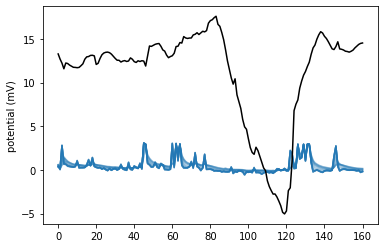

In [113]:
plt.plot((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T).T,'#2278B5',alpha=0.2)
plt.plot(SP_a,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.show()

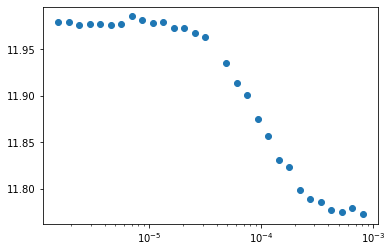

In [130]:
alpha_ens=pd.read_csv('data/alpha_ensemble_parameters.csv').iloc[:29,:]
#perm_ens.values.reshape(-1,)
plt.plot(alpha_ens,((((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T)-SP_a)**2).mean(axis=1))**0.5,'o')
plt.xscale('log')
#plt.yscale('log')

In [131]:
np.argmin((((((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T)-SP_a)**2).mean(axis=1))**0.5).values)

20

In [132]:
alpha_ens.values[20]

array([0.00080584])

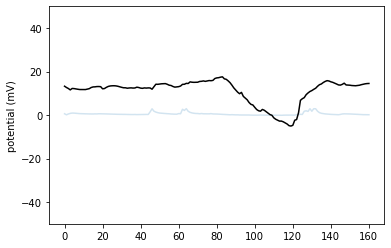

In [119]:
plt.plot((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T).T.iloc[:,20],'#2278B5',alpha=0.2)
plt.plot(SP_a,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

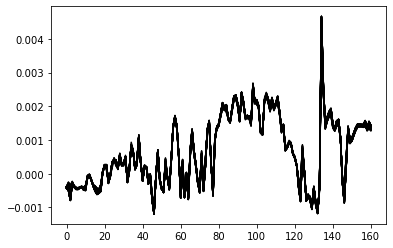

In [120]:
plt.plot(pd.DataFrame(a_all),'k')
plt.show()

In [121]:
pd.DataFrame(b_all).T

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
1,-0.026453,-0.010577,-0.077380,-0.033474,-0.029079,-0.025044,-0.023587,-0.021750,-0.019812,-0.021605,...,-0.003188,-0.000255,0.001703,0.002036,0.002742,0.003534,0.005007,0.005983,0.007352,0.007927
2,-0.032732,-0.006454,-0.053184,-0.048133,-0.040326,-0.034851,-0.031318,-0.027898,-0.025318,-0.026318,...,-0.009874,-0.006463,-0.003805,-0.002333,-0.001017,0.000197,0.002161,0.001585,0.003502,0.003337
3,-0.026444,-0.015424,-0.078498,-0.028392,-0.029805,-0.025354,-0.022868,-0.021331,-0.019726,-0.022024,...,-0.002492,0.000924,0.002783,0.002541,0.003188,0.003807,0.007004,0.004724,0.013287,0.009790
4,-0.025876,-0.014148,-0.076363,-0.028819,-0.031009,-0.026619,-0.024136,-0.022160,-0.020315,-0.022277,...,-0.003381,-0.000135,0.002010,0.002170,0.002741,0.003566,0.005925,0.003816,0.012902,0.010137
5,-0.035441,-0.004833,-0.039513,-0.049608,-0.044416,-0.039176,-0.034619,-0.031076,-0.028295,-0.028536,...,-0.012954,-0.009321,-0.006796,-0.005177,-0.003677,-0.002155,-0.000913,-0.000064,0.000583,0.000004
6,-0.029897,-0.008121,-0.070197,-0.042398,-0.033106,-0.029248,-0.026654,-0.024112,-0.021951,-0.023617,...,-0.005763,-0.002782,-0.000574,0.000499,0.001469,0.002963,0.004171,0.003869,0.006141,0.006007
7,-0.026090,-0.016111,-0.076602,-0.027488,-0.030277,-0.025624,-0.023641,-0.021887,-0.020114,-0.022394,...,-0.003833,0.000107,0.001953,0.001722,0.002591,0.003283,0.006373,0.003466,0.012839,0.008932
8,-0.026899,-0.015618,-0.076328,-0.030969,-0.030245,-0.025098,-0.023471,-0.021703,-0.019813,-0.022309,...,-0.002696,0.000672,0.002753,0.002421,0.003157,0.003781,0.006663,0.004745,0.013878,0.009771
9,-0.031072,-0.006639,-0.061967,-0.044492,-0.036736,-0.031859,-0.028868,-0.025808,-0.023339,-0.025000,...,-0.007509,-0.004291,-0.002010,-0.000822,0.000111,0.001412,0.002583,0.003186,0.004447,0.004460
10,-0.035567,-0.003320,-0.036042,-0.039344,-0.038923,-0.035651,-0.033057,-0.030191,-0.027983,-0.028151,...,-0.013208,-0.009206,-0.006683,-0.004921,-0.003563,-0.002389,-0.001165,-0.000162,0.000515,-0.000361


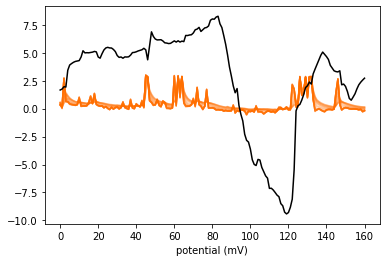

In [122]:
plt.plot((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T).T,'#FF6F00',alpha=0.2)
plt.plot(SP_b,'k-',markersize=3)
plt.xlabel('potential (mV)')
plt.show()

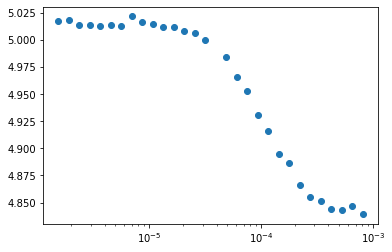

In [133]:
alpha_ens=pd.read_csv('data/alpha_ensemble_parameters.csv').iloc[:29,:]
#perm_ens.values.reshape(-1,)
plt.plot(alpha_ens,((((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T)-SP_b)**2).mean(axis=1))**0.5,'o')
plt.xscale('log')
#plt.yscale('log')

In [134]:
np.argmin((((((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T)-SP_b)**2).mean(axis=1))**0.5).values)

20

In [135]:
alpha_ens.values[20]

array([0.00080584])

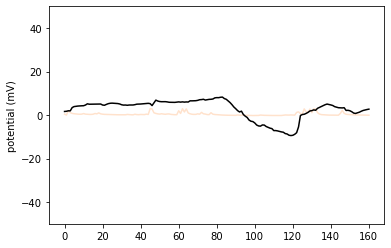

In [129]:
plt.plot((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T).T.iloc[:,5],'#FF6F00',alpha=0.2)
plt.plot(SP_b,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

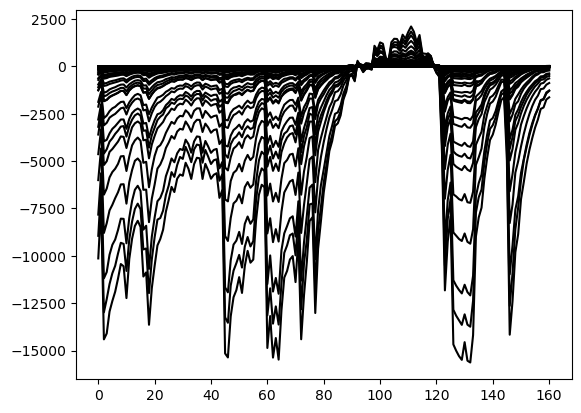

In [107]:
plt.plot(pd.DataFrame(c_all),'k')
plt.show()

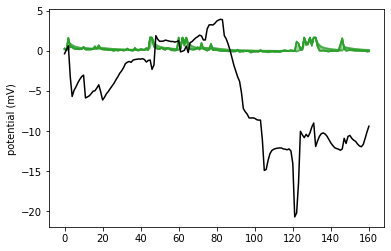

In [136]:
plt.plot((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T).T,'#2A9F2A',alpha=0.2)
plt.plot(SP_c,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.show()

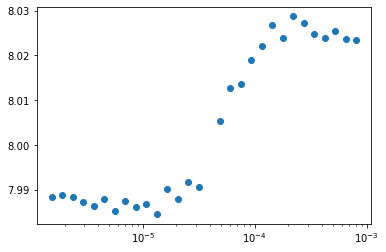

In [138]:
alpha_ens=pd.read_csv('data/alpha_ensemble_parameters.csv').iloc[:29,:]
#perm_ens.values.reshape(-1,)
plt.plot(alpha_ens,((((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T)-SP_c)**2).mean(axis=1))**0.5,'o')
plt.xscale('log')
#plt.yscale('log')

In [139]:
np.argmin((((((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T)-SP_c)**2).mean(axis=1))**0.5).values)

3

In [140]:
alpha_ens.values[3]

array([1.33352143e-05])

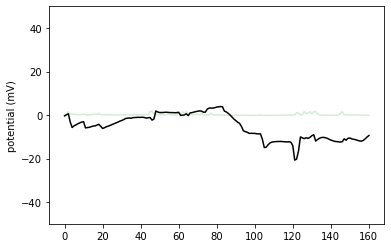

In [141]:
plt.plot((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T).T.iloc[:,3],'#2A9F2A',alpha=0.2)
plt.plot(SP_c,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

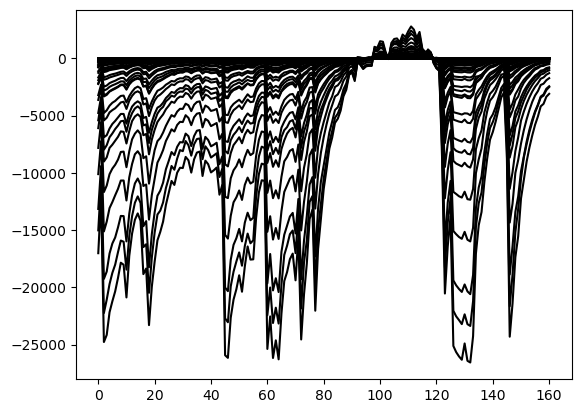

In [109]:
plt.plot(pd.DataFrame(d_all),'k')
plt.show()

In [139]:
from Read_data import convert
import time
import numpy as np
for i in range (30,31):
    convert('Por_ens/Por_ens_'+str(i))

C:\Users\m10921371\OneDrive - Colorado School of Mines\WADE_SFA\COMSOL_ATS\Read_data.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cond'][df["porosity"]>=0.4]=1/40
C:\Users\m10921371\OneDrive - Colorado School of Mines\WADE_SFA\COMSOL_ATS\Read_data.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['m']=0
C:\Users\m10921371\OneDrive - Colorado School of Mines\WADE_SFA\COMSOL_ATS\Read_data.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.o

In [143]:
a_all={}
b_all={}
c_all={}
d_all={}
#fig,ax=plt.subplots(1,3, figsize=(11,3))
for i in range(1,31):
    df=pd.read_csv('Por_ens/Por_ens_'+str(i)+'/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
    SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
    SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
    SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
    a=((df.iloc[1071,85:]).values*1000)
    b=((df.iloc[1312,85:]).values*1000)
    c=((df.iloc[759,85:]).values*1000)
    d=((df.iloc[708,85:]).values*1000)
    #residual[i]=sum((SP_a-a)**2),sum((SP_b-b)**2),sum((SP_c-c)**2),(sum((SP_a-a)**2)+sum((SP_b-b)**2)+sum((SP_c-c)**2))
    a_all[i]=a
    b_all[i]=b
    c_all[i]=c
    d_all[i]=d

FileNotFoundError: [Errno 2] No such file or directory: 'Por_ens/Por_ens_27/result.txt'

In [144]:
pd.DataFrame(a_all).T

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
1,-0.000407,-0.000449,-0.000834,-0.000286,-0.000347,-0.000408,-0.000423,-0.000393,-0.000377,-0.000447,...,0.001216,0.001388,0.001474,0.001477,0.001465,0.001494,0.001586,0.001345,0.001523,0.001431
2,-0.000400,-0.000431,-0.000780,-0.000293,-0.000360,-0.000429,-0.000440,-0.000400,-0.000379,-0.000445,...,0.001224,0.001371,0.001477,0.001476,0.001473,0.001480,0.001516,0.001531,0.001525,0.001411
3,-0.000356,-0.000397,-0.000724,-0.000241,-0.000305,-0.000372,-0.000384,-0.000354,-0.000338,-0.000403,...,0.001058,0.001185,0.001267,0.001280,0.001276,0.001320,0.001376,0.001313,0.001244,0.001188
4,-0.000368,-0.000418,-0.000783,-0.000263,-0.000347,-0.000411,-0.000420,-0.000383,-0.000365,-0.000433,...,0.001151,0.001287,0.001370,0.001378,0.001375,0.001422,0.001474,0.001373,0.001326,0.001329
5,-0.000389,-0.000445,-0.000848,-0.000404,-0.000423,-0.000459,-0.000469,-0.000428,-0.000408,-0.000476,...,0.001342,0.001497,0.001602,0.001604,0.001591,0.001581,0.001699,0.001461,0.001658,0.001503
6,-0.000432,-0.000478,-0.000861,-0.000302,-0.000399,-0.000470,-0.000479,-0.000439,-0.000416,-0.000484,...,0.001307,0.001464,0.001566,0.001575,0.001561,0.001568,0.001667,0.001566,0.001517,0.001466
7,-0.000334,-0.000372,-0.000678,-0.000212,-0.000276,-0.000341,-0.000353,-0.000327,-0.000313,-0.000375,...,0.000986,0.001101,0.001177,0.001186,0.001182,0.001215,0.001220,0.001128,0.001125,0.001115
8,-0.000343,-0.000385,-0.000682,-0.000228,-0.000306,-0.000365,-0.000374,-0.000344,-0.000329,-0.000389,...,0.001032,0.001152,0.001228,0.001239,0.001232,0.001256,0.001295,0.001303,0.001298,0.001170
9,-0.000377,-0.000420,-0.000772,-0.000262,-0.000348,-0.000413,-0.000422,-0.000386,-0.000364,-0.000431,...,0.001170,0.001314,0.001407,0.001420,0.001418,0.001425,0.001389,0.001324,0.001474,0.001340
10,-0.000402,-0.000457,-0.000852,-0.000358,-0.000391,-0.000451,-0.000473,-0.000437,-0.000413,-0.000485,...,0.001394,0.001552,0.001653,0.001668,0.001665,0.001697,0.001692,0.001597,0.001676,0.001549


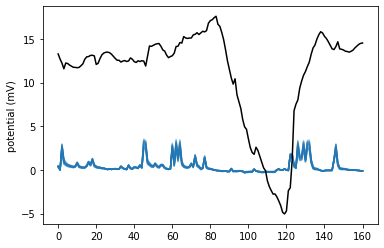

In [145]:
plt.plot((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T).T,'#2278B5',alpha=0.2)
plt.plot(SP_a,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.show()

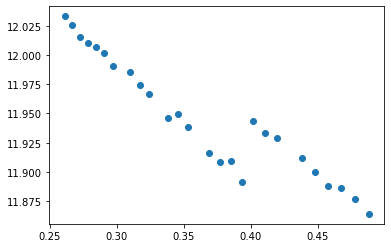

In [153]:
por_ens=pd.read_csv('data/por_ensemble_parameters.csv').iloc[:26,:]
#perm_ens.values.reshape(-1,)
plt.plot(alpha_ens,((((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T)-SP_a)**2).mean(axis=1))**0.5,'o')
#plt.xscale('log')
#plt.yscale('log')

In [154]:
np.argmin((((((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T)-SP_a)**2).mean(axis=1))**0.5).values)

20

In [155]:
por_ens.values[20]

array([0.48816317])

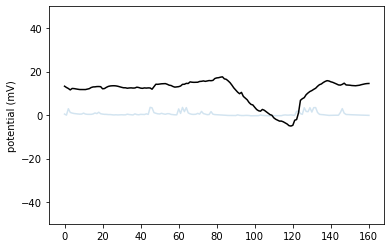

In [156]:
plt.plot((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T).T.iloc[:,20],'#2278B5',alpha=0.2)
plt.plot(SP_a,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

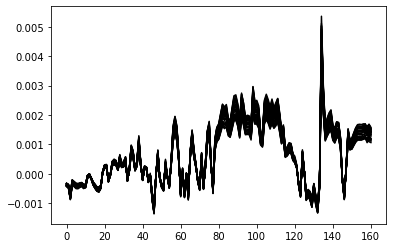

In [157]:
plt.plot(pd.DataFrame(a_all),'k')
plt.show()

In [158]:
pd.DataFrame(b_all).T

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
1,-0.028112,-0.009468,-0.077630,-0.034555,-0.029095,-0.025203,-0.023163,-0.021402,-0.019878,-0.021904,...,-0.003465,0.000757,0.001851,0.002078,0.002571,0.003735,0.005812,0.004542,0.008960,0.007972
2,-0.029187,-0.009294,-0.077644,-0.037155,-0.031322,-0.028228,-0.025947,-0.023380,-0.021156,-0.022908,...,-0.004583,-0.001611,0.000821,0.001304,0.002090,0.003153,0.004459,0.006199,0.008108,0.007532
3,-0.023648,-0.008553,-0.065846,-0.029450,-0.025245,-0.022798,-0.020894,-0.018989,-0.017419,-0.019239,...,-0.002946,-0.000533,0.001130,0.001723,0.002265,0.003577,0.005066,0.005924,0.006456,0.006220
4,-0.024990,-0.008588,-0.072232,-0.031593,-0.028475,-0.025347,-0.023130,-0.020794,-0.018880,-0.020930,...,-0.002670,-0.000126,0.001494,0.002029,0.002621,0.004070,0.005633,0.005952,0.006740,0.007367
5,-0.028453,-0.008450,-0.083184,-0.045649,-0.037029,-0.030369,-0.027910,-0.025216,-0.023057,-0.024688,...,-0.003758,-0.000796,0.001411,0.001827,0.002464,0.003268,0.005510,0.004727,0.009933,0.008108
6,-0.030465,-0.010163,-0.080519,-0.037372,-0.033019,-0.029555,-0.027012,-0.024524,-0.022390,-0.023806,...,-0.003935,-0.000860,0.001267,0.001857,0.002440,0.003403,0.005375,0.006148,0.007563,0.007680
7,-0.022260,-0.008671,-0.062391,-0.026253,-0.023164,-0.020818,-0.019093,-0.017474,-0.015903,-0.017848,...,-0.002386,-0.000298,0.001245,0.001749,0.002254,0.003355,0.004274,0.004466,0.005597,0.006039
8,-0.022637,-0.008525,-0.062816,-0.027818,-0.025345,-0.022423,-0.020329,-0.018469,-0.016990,-0.018690,...,-0.001871,0.000226,0.001657,0.002167,0.002597,0.003520,0.004613,0.006034,0.007595,0.006499
9,-0.027811,-0.008896,-0.075344,-0.035328,-0.030258,-0.027111,-0.024909,-0.022445,-0.020254,-0.021887,...,-0.004734,-0.001752,0.000436,0.001179,0.002000,0.002987,0.003591,0.004235,0.008815,0.007099
10,-0.029608,-0.008635,-0.085516,-0.043800,-0.034865,-0.029805,-0.028000,-0.025745,-0.023354,-0.025025,...,-0.003613,-0.000858,0.001305,0.002156,0.002999,0.004328,0.005329,0.005983,0.009037,0.008354


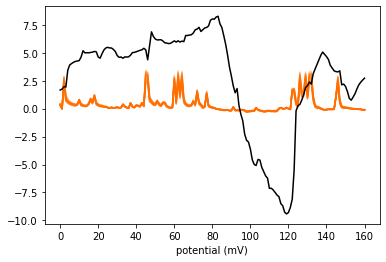

In [159]:
plt.plot((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T).T,'#FF6F00',alpha=0.2)
plt.plot(SP_b,'k-',markersize=3)
plt.xlabel('potential (mV)')
plt.show()

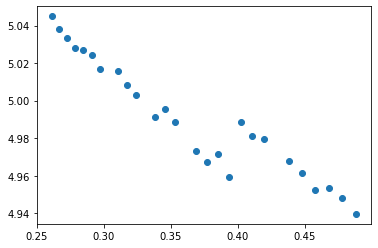

In [161]:
#alpha_ens=pd.read_csv('data/alpha_ensemble_parameters.csv').iloc[:29,:]
#perm_ens.values.reshape(-1,)
plt.plot(por_ens,((((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T)-SP_b)**2).mean(axis=1))**0.5,'o')
#plt.xscale('log')
#plt.yscale('log')

In [162]:
np.argmin((((((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T)-SP_b)**2).mean(axis=1))**0.5).values)

20

In [163]:
alpha_ens.values[20]

array([0.48816317])

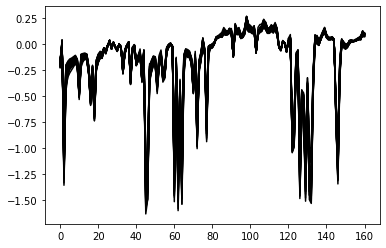

In [165]:
plt.plot(pd.DataFrame(c_all),'k')
plt.show()

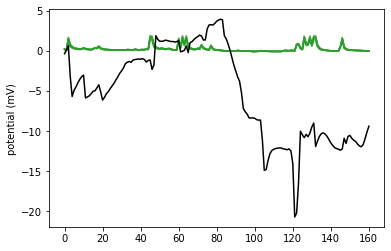

In [166]:
plt.plot((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T).T,'#2A9F2A',alpha=0.2)
plt.plot(SP_c,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.show()

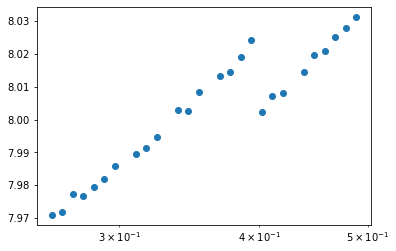

In [167]:
#alpha_ens=pd.read_csv('data/alpha_ensemble_parameters.csv').iloc[:29,:]
#perm_ens.values.reshape(-1,)
plt.plot(por_ens,((((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T)-SP_c)**2).mean(axis=1))**0.5,'o')
plt.xscale('log')
#plt.yscale('log')

In [168]:
np.argmin((((((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T)-SP_c)**2).mean(axis=1))**0.5).values)

14

In [170]:
por_ens.values[14]

array([0.26102975])

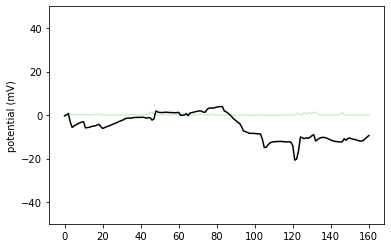

In [171]:
plt.plot((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T).T.iloc[:,14],'#2A9F2A',alpha=0.2)
plt.plot(SP_c,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

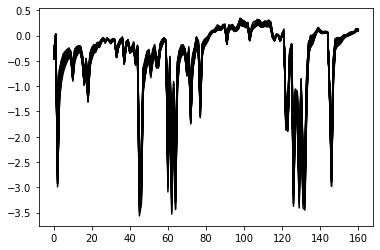

In [172]:
plt.plot(pd.DataFrame(d_all),'k')
plt.show()

In [140]:
from Read_data import convert
import time
import numpy as np
for i in range (30,31):
    convert('Res_sat_ens/Res_sat_ens_'+str(i))

C:\Users\m10921371\OneDrive - Colorado School of Mines\WADE_SFA\COMSOL_ATS\Read_data.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cond'][df["porosity"]>=0.4]=1/40
C:\Users\m10921371\OneDrive - Colorado School of Mines\WADE_SFA\COMSOL_ATS\Read_data.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['m']=0
C:\Users\m10921371\OneDrive - Colorado School of Mines\WADE_SFA\COMSOL_ATS\Read_data.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.o

In [173]:
a_all={}
b_all={}
c_all={}
d_all={}
#fig,ax=plt.subplots(1,3, figsize=(11,3))
for i in range(1,9):
    df=pd.read_csv('Res_sat_ens/Res_sat_ens_'+str(i)+'/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
    SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
    SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
    SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
    a=((df.iloc[1071,85:]).values*1000)
    b=((df.iloc[1312,85:]).values*1000)
    c=((df.iloc[759,85:]).values*1000)
    d=((df.iloc[708,85:]).values*1000)
    #residual[i]=sum((SP_a-a)**2),sum((SP_b-b)**2),sum((SP_c-c)**2),(sum((SP_a-a)**2)+sum((SP_b-b)**2)+sum((SP_c-c)**2))
    a_all[i]=a
    b_all[i]=b
    c_all[i]=c
    d_all[i]=d

FileNotFoundError: [Errno 2] No such file or directory: 'Res_sat_ens/Res_sat_ens_9/result.txt'

In [174]:
pd.DataFrame(a_all).T

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
1,-0.000382,-0.000421,-0.000770,-0.000287,-0.000373,-0.000431,-0.000437,-0.000399,-0.000375,-0.000438,...,0.001219,0.001357,0.001455,0.001454,0.001443,0.001433,0.001414,0.001391,0.001430,0.001395
2,-0.000354,-0.000414,-0.000771,-0.000339,-0.000351,-0.000405,-0.000418,-0.000384,-0.000365,-0.000433,...,0.001203,0.001366,0.001462,0.001460,0.001446,0.001468,0.001564,0.001312,0.001500,0.001388
3,-0.000378,-0.000418,-0.000764,-0.000294,-0.000364,-0.000426,-0.000434,-0.000397,-0.000374,-0.000434,...,0.001216,0.001364,0.001447,0.001457,0.001453,0.001472,0.001490,0.001356,0.001491,0.001372
4,-0.000374,-0.000415,-0.000759,-0.000299,-0.000331,-0.000390,-0.000409,-0.000381,-0.000360,-0.000423,...,0.001220,0.001357,0.001453,0.001454,0.001447,0.001449,0.001402,0.001345,0.001501,0.001419
5,-0.000390,-0.000427,-0.000745,-0.000285,-0.000371,-0.000412,-0.000417,-0.000387,-0.000369,-0.000436,...,0.001222,0.001359,0.001459,0.001457,0.001447,0.001437,0.001550,0.001323,0.001509,0.001367
6,-0.000393,-0.000423,-0.000729,-0.000274,-0.000351,-0.000419,-0.000430,-0.000394,-0.000371,-0.000434,...,0.001221,0.001359,0.001455,0.001456,0.001451,0.001481,0.001511,0.001312,0.001506,0.001402
7,-0.000390,-0.000415,-0.000714,-0.000283,-0.000372,-0.000429,-0.000436,-0.000399,-0.000376,-0.000435,...,0.001216,0.001361,0.001443,0.001458,0.001453,0.001485,0.001497,0.001338,0.001497,0.001374
8,-0.000378,-0.000418,-0.000765,-0.000276,-0.000355,-0.000421,-0.000430,-0.000394,-0.000370,-0.000433,...,0.001185,0.001322,0.001440,0.001439,0.001431,0.001463,0.001511,0.001299,0.001491,0.001376


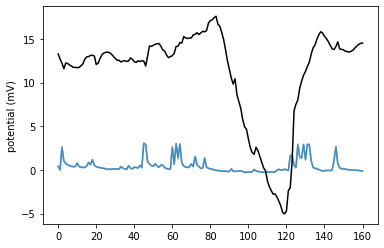

In [175]:
plt.plot((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T).T,'#2278B5',alpha=0.2)
plt.plot(SP_a,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.show()

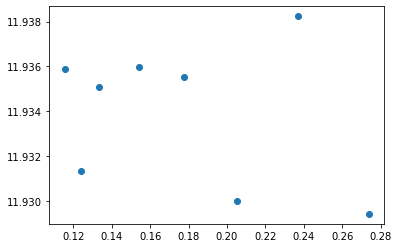

In [177]:
res_sat_ens=pd.read_csv('data/res_sat_ensemble_parameters.csv').iloc[:8,:]
#perm_ens.values.reshape(-1,)
plt.plot(res_sat_ens,((((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T)-SP_a)**2).mean(axis=1))**0.5,'o')
#plt.xscale('log')
#plt.yscale('log')

In [178]:
np.argmin((((((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T)-SP_a)**2).mean(axis=1))**0.5).values)

4

In [180]:
res_sat_ens.values[4]

array([0.27384196])

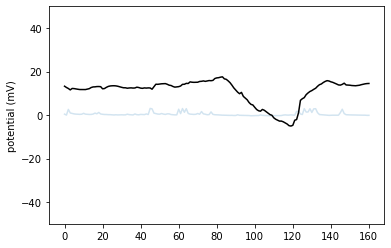

In [182]:
plt.plot((pd.DataFrame(a_all).T-pd.DataFrame(d_all).T).T.iloc[:,4],'#2278B5',alpha=0.2)
plt.plot(SP_a,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

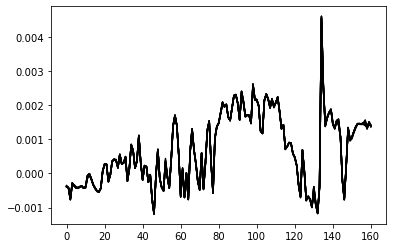

In [183]:
plt.plot(pd.DataFrame(a_all),'k')
plt.show()

In [184]:
pd.DataFrame(b_all).T

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
1,-0.027784,-0.008564,-0.075921,-0.036275,-0.032633,-0.028630,-0.025979,-0.023463,-0.021102,-0.022493,...,-0.003226,-0.000778,0.001249,0.001698,0.002329,0.003163,0.003930,0.005039,0.007441,0.007617
2,-0.025482,-0.008089,-0.074406,-0.040389,-0.030887,-0.026565,-0.024500,-0.022345,-0.020231,-0.022018,...,-0.003662,0.000281,0.001837,0.002004,0.002472,0.003593,0.005811,0.003987,0.008794,0.007718
3,-0.027841,-0.008356,-0.076023,-0.037977,-0.031946,-0.028452,-0.025906,-0.023481,-0.021150,-0.022506,...,-0.003346,-0.000509,0.001136,0.001734,0.002441,0.003517,0.004596,0.004790,0.008375,0.007390
4,-0.027248,-0.008648,-0.075107,-0.038286,-0.029778,-0.025702,-0.024097,-0.022239,-0.020129,-0.021969,...,-0.003239,-0.000808,0.001176,0.001679,0.002358,0.003314,0.003782,0.004373,0.008847,0.007956
5,-0.028493,-0.009292,-0.074202,-0.036345,-0.032199,-0.026941,-0.024082,-0.022278,-0.020396,-0.022313,...,-0.003173,-0.000709,0.001385,0.001779,0.002379,0.003089,0.005206,0.004341,0.009241,0.007359
6,-0.028619,-0.009222,-0.073380,-0.036571,-0.030701,-0.027614,-0.025396,-0.023014,-0.020853,-0.022402,...,-0.003247,-0.000748,0.001219,0.001707,0.002388,0.003624,0.004878,0.003973,0.009043,0.007748
7,-0.028626,-0.008701,-0.072361,-0.036570,-0.032851,-0.028730,-0.026111,-0.023667,-0.021340,-0.022403,...,-0.003255,-0.000775,0.001087,0.001793,0.002423,0.003699,0.004781,0.004636,0.008631,0.007573
8,-0.027561,-0.008381,-0.075955,-0.037498,-0.031330,-0.028044,-0.025725,-0.023223,-0.020903,-0.022732,...,-0.005438,-0.002497,0.000354,0.000804,0.001521,0.002846,0.004397,0.003395,0.008271,0.007281


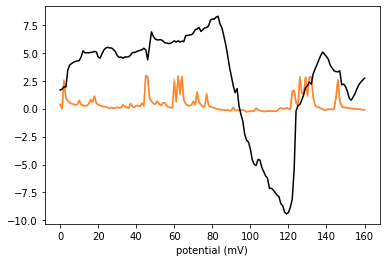

In [185]:
plt.plot((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T).T,'#FF6F00',alpha=0.2)
plt.plot(SP_b,'k-',markersize=3)
plt.xlabel('potential (mV)')
plt.show()

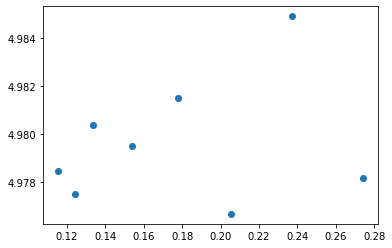

In [187]:
#alpha_ens=pd.read_csv('data/alpha_ensemble_parameters.csv').iloc[:29,:]
#perm_ens.values.reshape(-1,)
plt.plot(res_sat_ens,((((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T)-SP_b)**2).mean(axis=1))**0.5,'o')
#plt.xscale('log')
#plt.yscale('log')

In [188]:
np.argmin((((((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T)-SP_b)**2).mean(axis=1))**0.5).values)

5

In [189]:
alpha_ens.values[5]

array([0.38498163])

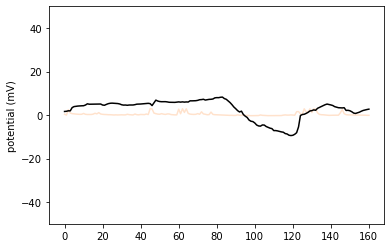

In [190]:
plt.plot((pd.DataFrame(b_all).T-pd.DataFrame(d_all).T).T.iloc[:,5],'#FF6F00',alpha=0.2)
plt.plot(SP_b,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

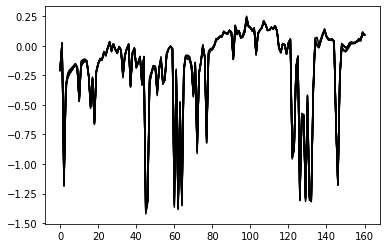

In [191]:
plt.plot(pd.DataFrame(c_all),'k')
plt.show()

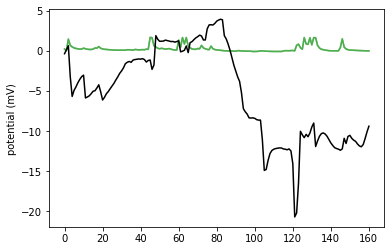

In [192]:
plt.plot((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T).T,'#2A9F2A',alpha=0.2)
plt.plot(SP_c,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.show()

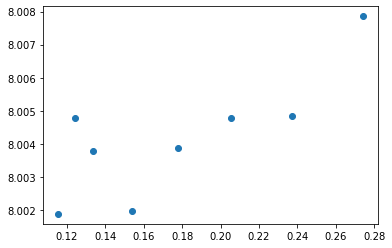

In [194]:
#alpha_ens=pd.read_csv('data/alpha_ensemble_parameters.csv').iloc[:29,:]
#perm_ens.values.reshape(-1,)
plt.plot(res_sat_ens,((((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T)-SP_c)**2).mean(axis=1))**0.5,'o')
#plt.xscale('log')
#plt.yscale('log')

In [195]:
np.argmin((((((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T)-SP_c)**2).mean(axis=1))**0.5).values)

6

In [196]:
alpha_ens.values[6]

array([0.27254612])

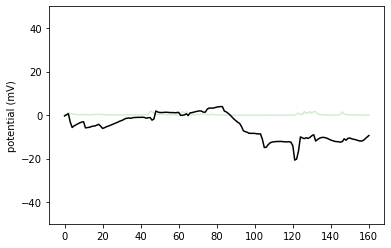

In [197]:
plt.plot((pd.DataFrame(c_all).T-pd.DataFrame(d_all).T).T.iloc[:,6],'#2A9F2A',alpha=0.2)
plt.plot(SP_c,'k-',markersize=3)
plt.ylabel('potential (mV)')
plt.ylim(-50,50)
plt.show()

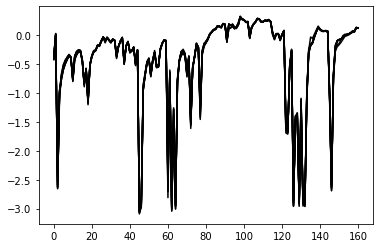

In [198]:
plt.plot(pd.DataFrame(d_all),'k')
plt.show()